# LISA M1 Catalog

In [18]:
# Standard libraries for data handling and analysis
import h5py  # For reading HDF5 data files
import numpy as np  # Numerical operations
import glob  # File pattern matching
import json  # JSON file handling
import os
import matplotlib.pyplot as plt  # Plotting
import matplotlib.cm as cm  # Colormaps
from matplotlib.colors import Normalize
from scipy.interpolate import interp1d  # 1D interpolation
from math import log10, floor  # Mathematical functions

# Interactive widgets for parameter exploration
from ipywidgets import Dropdown, FloatSlider, HBox, Output, interact, widgets
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

# Custom cosmology utilities (from common.py)
from common import CosmoInt  # Cosmology interpolator for distance-redshift conversions
from common import ref_cosmo  # Reference cosmology (FlatLambdaCDM)

# Configure matplotlib for publication-quality plots
plt.rcParams.update({'font.size': 18})
plt.rcParams['figure.figsize'] = (16, 9)  # Double-column paper width

# Cosmology: Redshift to Luminosity Distance

This section verifies the cosmology model by plotting the relationship between redshift *z* and luminosity distance *Dₗ*. The `CosmoInt` utility provides fast interpolated conversions between these quantities using the Planck 2018 cosmological parameters.

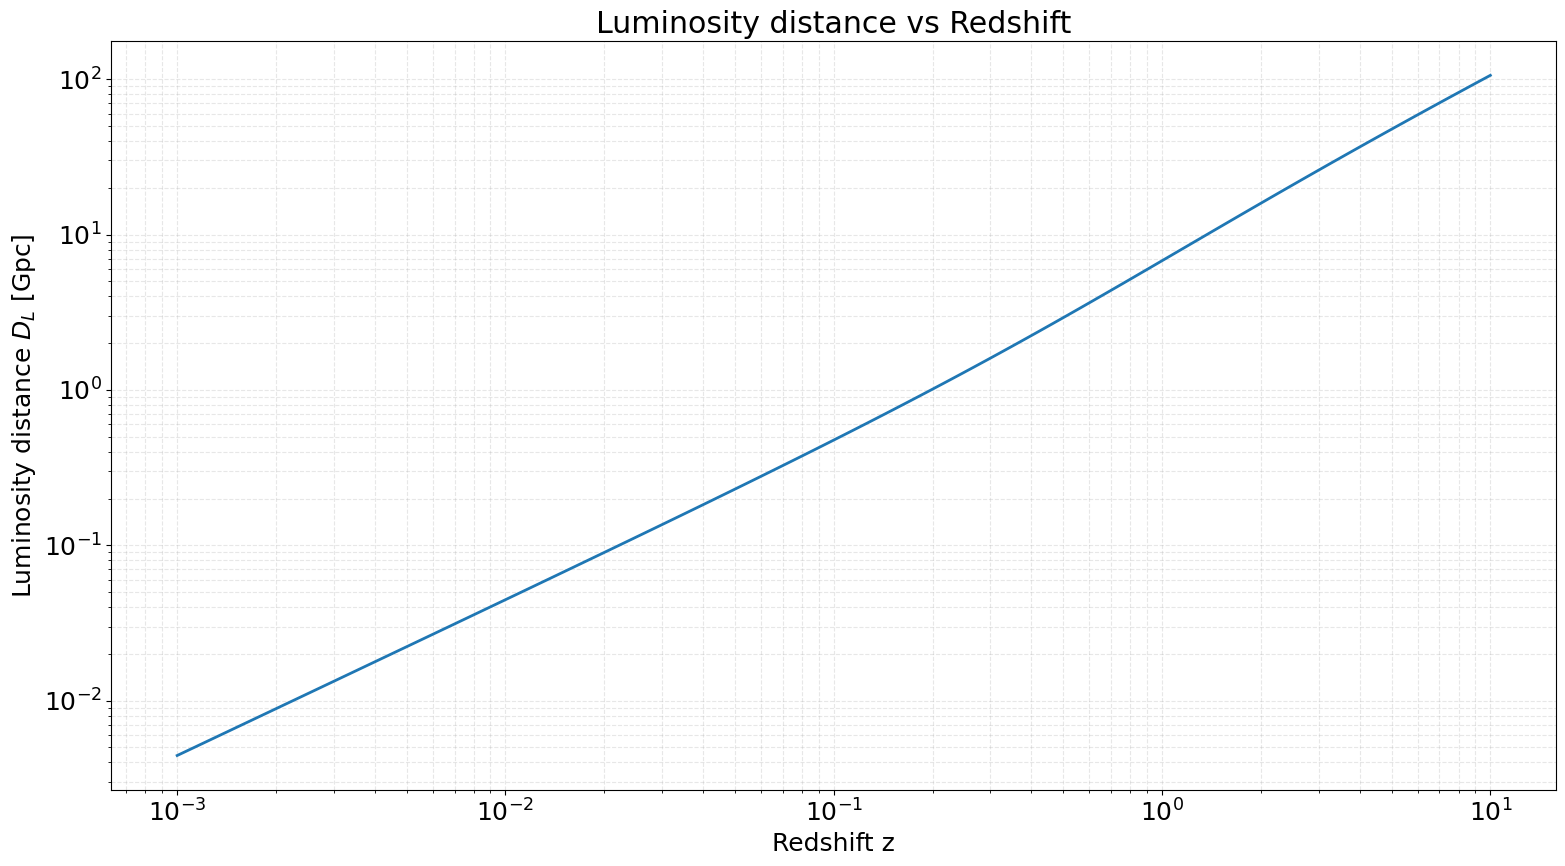

Distance at z = 0.01: 0.0446 Gpc


In [19]:
# Create redshift array spanning z = 0.001 to z = 10
z_vec = np.logspace(-3, 1, 100)

# Convert to luminosity distances (in Gpc)
d_vec = CosmoInt.get_luminosity_distance(z_vec)

# Plot redshift-distance relation
plt.figure()
plt.plot(z_vec, d_vec, linewidth=2)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Redshift z')
plt.ylabel(r'Luminosity distance $D_L$ [Gpc]')
plt.title('Luminosity distance vs Redshift')
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()
plt.show()

# Example: Get distance at z = 0.01
print(f"Distance at z = 0.01: {CosmoInt.get_luminosity_distance(1e-2):.4f} Gpc")

# Parameter Estimation: Fisher Matrix Analysis

This section analyzes how well LISA can measure EMRI source parameters using Fisher matrix techniques. The analysis includes:

**Circular Orbits**: 12-parameter Fisher matrix (M, μ, a, p₀, θₛ, φₛ, θₖ, φₖ, Φ₀, dist, Ωₛ, t₀)
**Eccentric Orbits**: 14-parameter Fisher matrix (adds e₀ and Φₑ)

The "detector frame" masses are redshifted: M_det = (1+z)×M_source

Parameter estimation precision depends on:
- Source SNR (higher SNR → better precision)
- Sky location and orientation (affects antenna pattern)
- Orbital geometry (eccentricity, spin alignment)
- Mission lifetime (longer observations → better constraints)

In [20]:
# Load all inference.h5 files from inference_* directories
# Each file contains Fisher matrix parameter estimation results for both circular and eccentric orbits
inference_files = sorted(glob.glob('M1_inference_*/inference.h5'))
print(f"Found {len(inference_files)} inference.h5 files")

# Dictionaries to store inference results indexed by (source_id, run_type)
# run_type is either 'circular' (12 params) or 'eccentric' (14 params)
inference_metadata = {}           # Source configuration and SNR
inference_precision_data = {}     # Parameter estimation uncertainties

for idx, inf_file in enumerate(inference_files):
    # Extract source ID from directory name
    source_id = int(inf_file.split('_')[2].split('/')[0])
    
    with h5py.File(inf_file, 'r') as f:
        # Loop through both 'circular' and 'eccentric' runs
        for run_type in ['circular', 'eccentric']:
            if run_type not in f.keys():
                print(f"  Warning: {run_type} run not found in {inf_file}")
                continue
            
            run_group = f[run_type]
            source_key = (source_id, run_type)
            
            # Extract source metadata and configuration
            inference_metadata[source_key] = {
                'm1': float(np.round(run_group['m1'][()], decimals=5)),     # Primary mass [M☉]
                'm2': float(np.round(run_group['m2'][()], decimals=5)),     # Secondary mass [M☉]
                'a': float(run_group['a'][()]),                              # Spin parameter
                'p0': float(run_group['p0'][()]),                            # Initial semi-latus rectum [M]
                'e0': float(run_group['e0'][()]),                            # Initial eccentricity
                'e_f': float(run_group['e_f'][()]),                          # Final eccentricity
                'dist': float(run_group['dist'][()]),                        # Luminosity distance [Gpc]
                'T': float(np.round(run_group['Tpl'][()], decimals=5)),      # Mission lifetime [years]
                'redshift': float(run_group['redshift'][()]),                # Redshift
                'snr': run_group['snr'][()],                                 # SNR array (100 realizations)
                'run_type': run_type,
                'fish_params': run_group['fish_params'][()],                 # Injected parameters for Fisher matrix
            }
            
            # Extract parameter names (different for circular vs eccentric)
            param_names = run_group['param_names'][()]
            param_names = np.array(param_names, dtype=str).tolist()
            inference_metadata[source_key]['param_names'] = param_names
            
            # Extract measurement precision arrays (shape: 100 realizations × n_params)
            detector_precision = run_group['detector_measurement_precision'][()]  # Detector frame (redshifted)
            source_precision = run_group['source_measurement_precision'][()]      # Source frame
            
            # Convert absolute uncertainties to relative uncertainties for easier interpretation
            inference_precision_data[source_key] = {}
            
            for ii, name in enumerate(param_names):
                if name == 'M':  # Primary mass (detector frame M_det = (1+z)M_source)
                    inference_precision_data[source_key].update({
                        "relative_precision_m1_det": detector_precision[:, ii] / 
                                                      (inference_metadata[source_key]['m1'] * 
                                                       (1 + inference_metadata[source_key]['redshift'])),
                        "relative_precision_m1": source_precision[:, ii] / inference_metadata[source_key]['m1']
                    })
                elif name == 'mu':  # Secondary mass (reduced mass)
                    inference_precision_data[source_key].update({
                        "relative_precision_m2_det": detector_precision[:, ii] / 
                                                      (inference_metadata[source_key]['m2'] * 
                                                       (1 + inference_metadata[source_key]['redshift'])),
                        "relative_precision_m2": source_precision[:, ii] / inference_metadata[source_key]['m2']
                    })
                elif name == 'e0':  # Initial eccentricity (eccentric orbits only)
                    inference_precision_data[source_key].update({
                        "relative_precision_e0": detector_precision[:, ii] / inference_metadata[source_key]['e0']
                    })
                else:  # Other parameters (angles, distance, spin, etc.)
                    inference_precision_data[source_key].update({
                        "absolute_precision_" + name: detector_precision[:, ii]
                    })
                
                # Add relative precision for distance and spin
                if name == 'dist':
                    inference_precision_data[source_key].update({
                        "relative_precision_" + name: detector_precision[:, ii] / inference_metadata[source_key][name]
                    })
                if name == 'a':
                    inference_precision_data[source_key].update({
                        "relative_precision_" + name: detector_precision[:, ii] / inference_metadata[source_key][name]
                    })
            
            # Store SNR array for reference
            inference_precision_data[source_key].update({"snr": run_group['snr'][()]})

print("\nInference data loading complete!")
print(f"Loaded metadata for {len(inference_metadata)} source configurations (circular + eccentric runs)")
print(f"Loaded parameter estimation precision data for {len(inference_precision_data)} runs")

# List available precision metrics
list_key_err = list(inference_precision_data[(0, 'eccentric')].keys())
print(f"Available precision metrics: {list_key_err}")

# Extract unique parameter values for inference analysis widgets
m2_values_inf = sorted(set(inference_metadata[src]['m2'] for src in inference_metadata))
a_values_inf = sorted(set(inference_metadata[src]['a'] for src in inference_metadata))
tpl_values_inf = sorted(set(inference_metadata[src]['T'] for src in inference_metadata))
print(f"\nInference parameter space:")
print(f"  Spin values: {a_values_inf}")
print(f"  Secondary mass values: {len(m2_values_inf)} unique values")
print(f"  Mission lifetime values: {tpl_values_inf} years")

Found 12 inference.h5 files

Inference data loading complete!
Loaded metadata for 12 source configurations (circular + eccentric runs)
Loaded parameter estimation precision data for 12 runs
Available precision metrics: ['relative_precision_m1_det', 'relative_precision_m1', 'relative_precision_m2_det', 'relative_precision_m2', 'absolute_precision_a', 'relative_precision_a', 'absolute_precision_p0', 'relative_precision_e0', 'absolute_precision_dist', 'relative_precision_dist', 'absolute_precision_qS', 'absolute_precision_phiS', 'absolute_precision_qK', 'absolute_precision_phiK', 'absolute_precision_Phi_phi0', 'absolute_precision_Phi_r0', 'absolute_precision_OmegaS', 'absolute_precision_DeltaV', 'snr']

Inference parameter space:
  Spin values: [0.9692, 0.9712, 0.9784, 0.9805, 0.9808, 0.9842, 0.988, 0.9882, 0.9891, 0.9908, 0.9935, 0.998]
  Secondary mass values: 12 unique values
  Mission lifetime values: [0.06396, 0.19289, 0.22037, 0.28198, 0.39901, 0.40257, 0.96776, 1.27249, 1.31703, 1.

/var/folders/78/stbtx34d7vj939lq8bmh39wrx379gb/T/ipykernel_1240/2255693220.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1200x600 with 0 Axes>

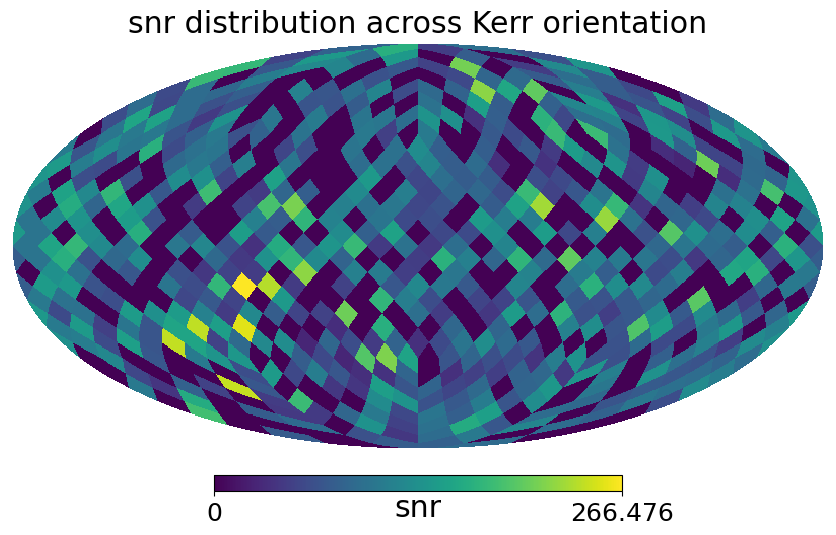

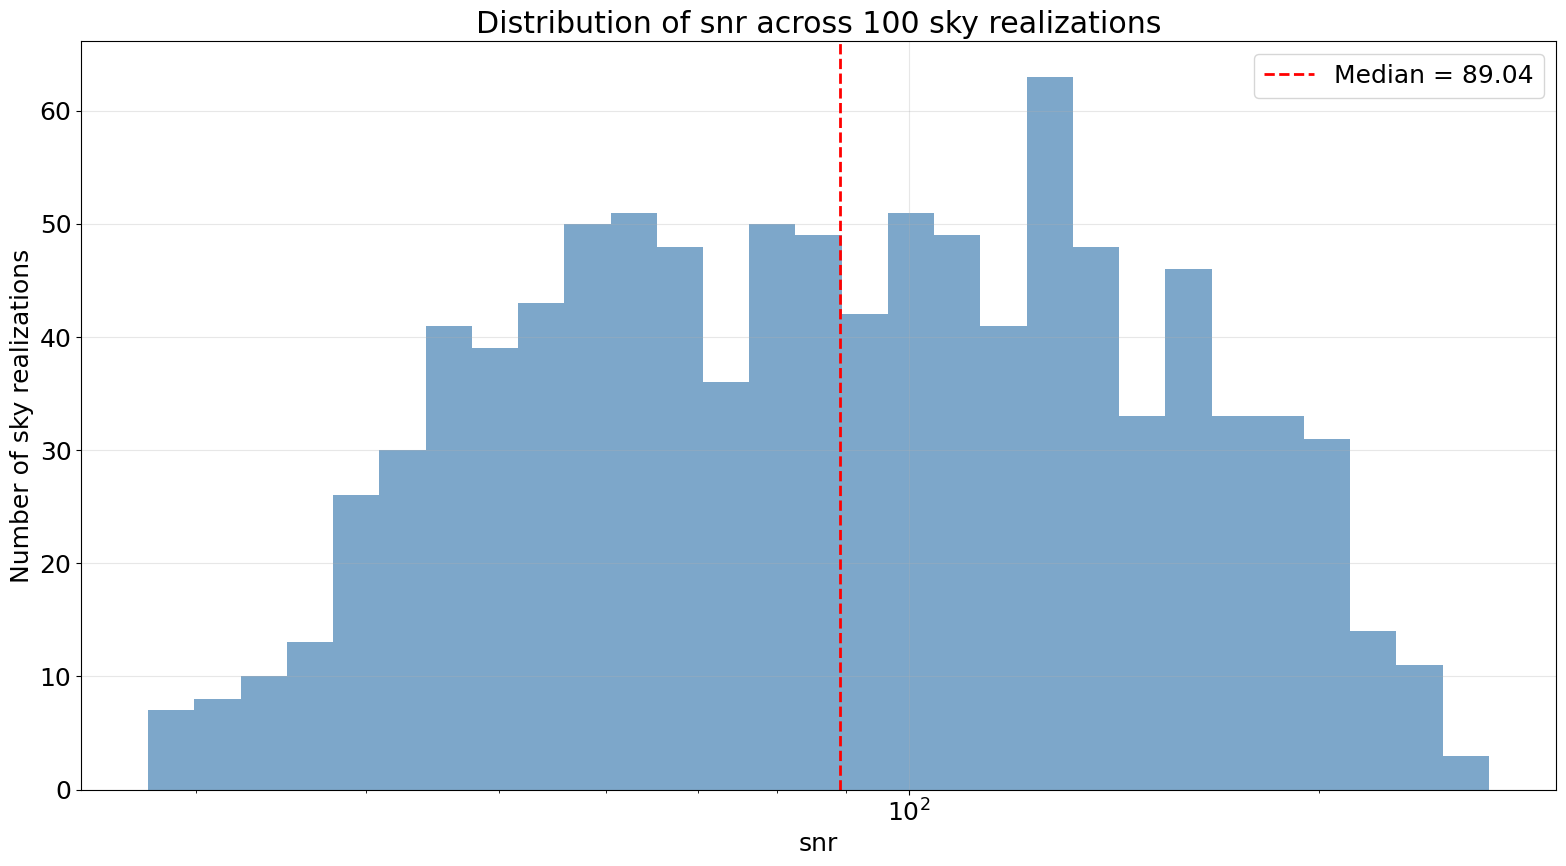

In [21]:
from mpl_toolkits.mplot3d import Axes3D
import healpy as hp

# Visualize sky distribution of measurement precision using HEALPix projection
# This shows how parameter estimation quality varies with source sky location

# Extract angular coordinates from Fisher matrix parameters for source_id=0, eccentric orbit
param_names = inference_metadata[(0, 'eccentric')]['param_names']

# Kerr spin angular momentum direction (θₖ, φₖ)
phi_K = inference_metadata[(0, 'eccentric')]['fish_params'][:, param_names.index('phiK')]
theta_K = inference_metadata[(0, 'eccentric')]['fish_params'][:, param_names.index('qK')]

# Source sky position (θₛ, φₛ)
phi_S = inference_metadata[(0, 'eccentric')]['fish_params'][:, param_names.index('phiS')]
theta_S = inference_metadata[(0, 'eccentric')]['fish_params'][:, param_names.index('qS')]

# Select metric to visualize (e.g., SNR, distance precision, mass precision)
metric_mollview = 'snr'
plot_on_sky = inference_precision_data[(0, 'eccentric')][metric_mollview]

# Create HEALPix sky map (nside=8 gives 768 pixels on the sphere)
plt.figure(figsize=(12, 6))
nside = 8
npix = hp.nside2npix(nside)
sky_map = np.zeros(npix)

# Map each source realization to a HEALPix pixel based on Kerr spin orientation
pixels = hp.ang2pix(nside, theta_K, phi_K)

# Accumulate values in each pixel and compute average
for i, pix in enumerate(pixels):
    sky_map[pix] += plot_on_sky[i]

counts = np.bincount(pixels, minlength=npix)
counts[counts == 0] = 1  # Avoid division by zero
sky_map = sky_map / counts  # Average value per pixel

# Plot Mollweide projection of the sky map
hp.mollview(sky_map, title=f'{metric_mollview} distribution across Kerr orientation', 
            cmap="viridis", unit=metric_mollview)
plt.tight_layout()
# plt.savefig(f'mollview_{metric_mollview}.png', dpi=300, bbox_inches='tight')
plt.show()

# Histogram of the metric distribution across all sky realizations
plt.figure()
bins = np.logspace(np.log10(np.min(plot_on_sky)), np.log10(np.max(plot_on_sky)), 30)
plt.hist(plot_on_sky, bins=bins, histtype='stepfilled', alpha=0.7, color='steelblue')
plt.axvline(np.median(plot_on_sky), color='r', linestyle='dashed', linewidth=2, 
            label=f'Median = {np.median(plot_on_sky):.2f}')
plt.xlabel(metric_mollview)
plt.ylabel("Number of sky realizations")
plt.xscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title(f'Distribution of {metric_mollview} across 100 sky realizations')
plt.tight_layout()
# plt.savefig(f'histogram_{metric_mollview}.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
# Select a specific source for detailed sky location analysis
key_source = (0, 'eccentric')

# Extract angular coordinates for this source
param_names = inference_metadata[key_source]['param_names']

# Kerr spin angular momentum direction
phi_K = inference_metadata[key_source]['fish_params'][:, param_names.index('phiK')]
theta_K = inference_metadata[key_source]['fish_params'][:, param_names.index('qK')]

# Source sky position  
phi_S = inference_metadata[key_source]['fish_params'][:, param_names.index('phiS')]
theta_S = inference_metadata[key_source]['fish_params'][:, param_names.index('qS')]

# Uncomment to visualize normalized coordinates:
# plt.plot(theta_S/np.pi, phi_S/(2*np.pi), '.')
# plt.xlabel('θ / π')
# plt.ylabel('φ / 2π')

/var/folders/78/stbtx34d7vj939lq8bmh39wrx379gb/T/ipykernel_1240/2418661253.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1200x600 with 0 Axes>

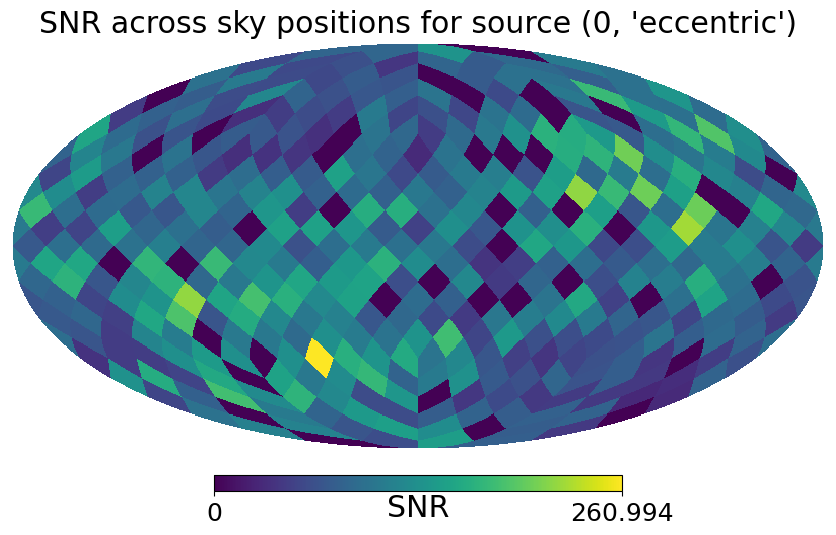

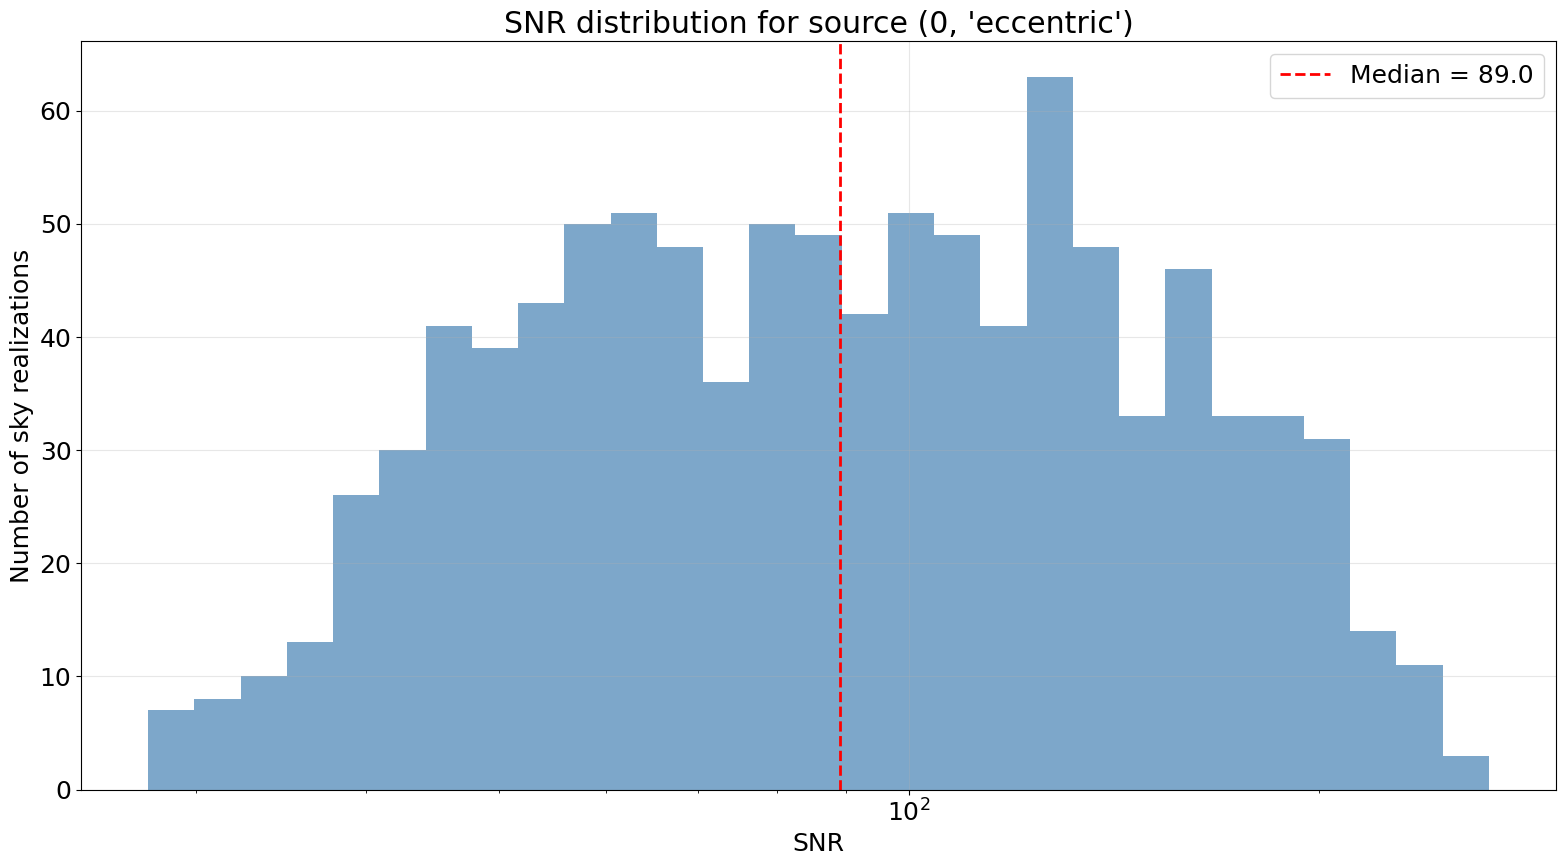

In [23]:
# Visualize SNR (or other metric) distribution across the sky for the selected source
# This uses the source sky position (θₛ, φₛ) rather than Kerr orientation

# Select metric to plot (can also use: 'relative_precision_dist', etc.)
plot_on_sky = inference_metadata[key_source]['snr']
# plot_on_sky = inference_precision_data[key_source]['relative_precision_dist']

# Create HEALPix sky map
plt.figure(figsize=(12, 6))
nside = 6  # Lower resolution for this example
npix = hp.nside2npix(nside)
sky_map = np.zeros(npix)

# Map to pixels based on source sky location (θₛ, φₛ)
pixels = hp.ang2pix(nside, theta_S, phi_S)

# Accumulate and average values in each pixel
for i, pix in enumerate(pixels):
    sky_map[pix] += plot_on_sky[i]

counts = np.bincount(pixels, minlength=npix)
counts[counts == 0] = 1
sky_map = sky_map / counts

# Mollweide projection of sky distribution
hp.mollview(sky_map, title=f"SNR across sky positions for source {key_source}", 
            cmap="viridis", unit="SNR")
plt.tight_layout()
plt.show()

# Histogram of SNR values across sky realizations
plt.figure()
bins = np.logspace(np.log10(np.min(plot_on_sky)), np.log10(np.max(plot_on_sky)), 30)
plt.hist(plot_on_sky, bins=bins, histtype='stepfilled', alpha=0.7, color='steelblue')
plt.axvline(np.median(plot_on_sky), color='r', linestyle='dashed', linewidth=2, 
            label=f'Median = {np.median(plot_on_sky):.1f}')
plt.xlabel("SNR")
plt.ylabel("Number of sky realizations")
plt.xscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title(f'SNR distribution for source {key_source}')
plt.tight_layout()
plt.show()

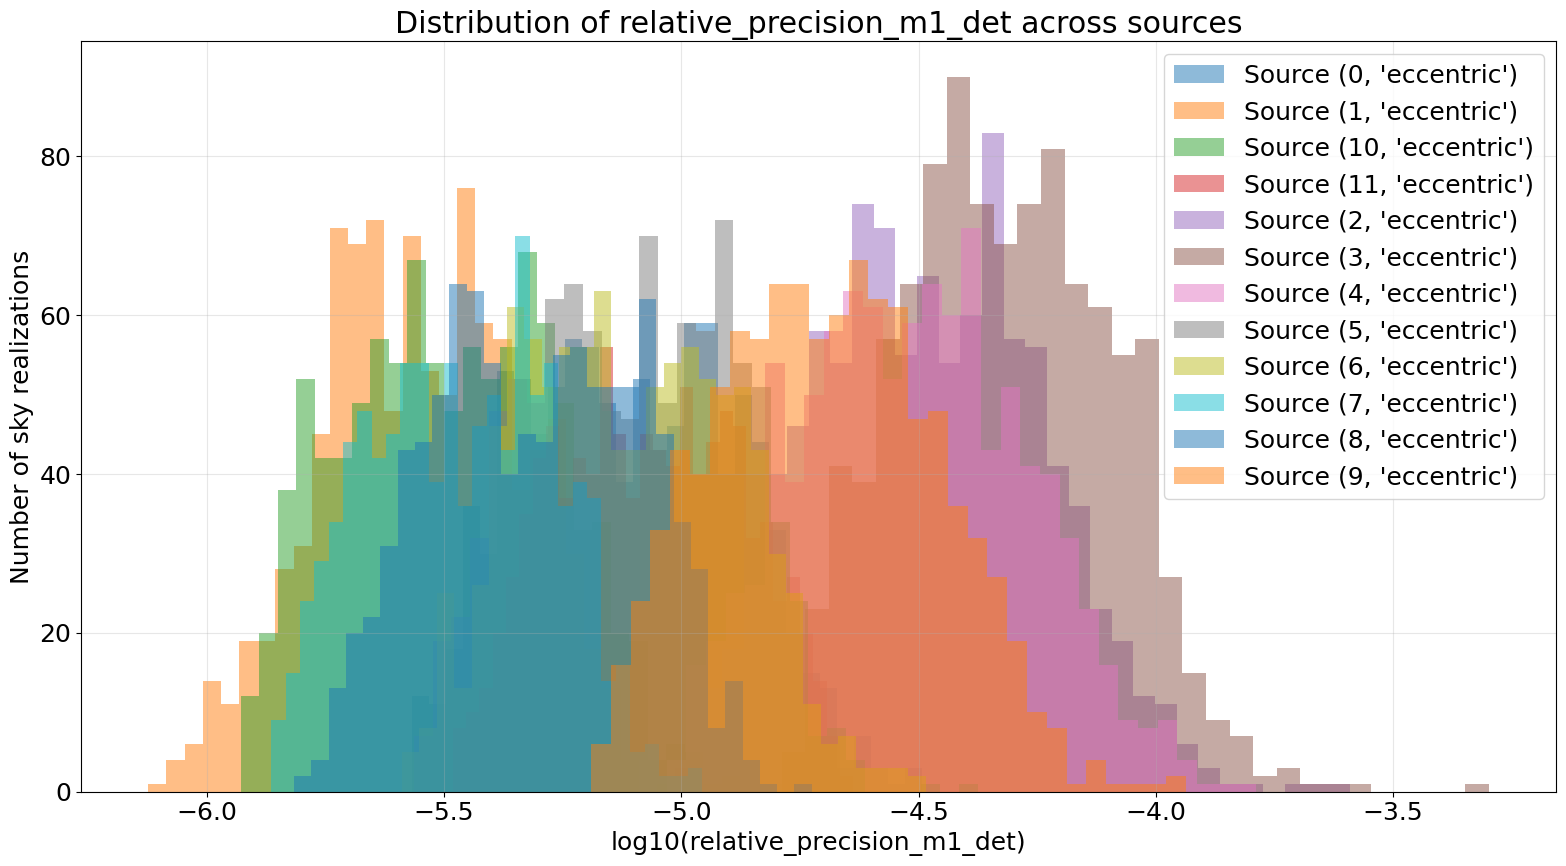

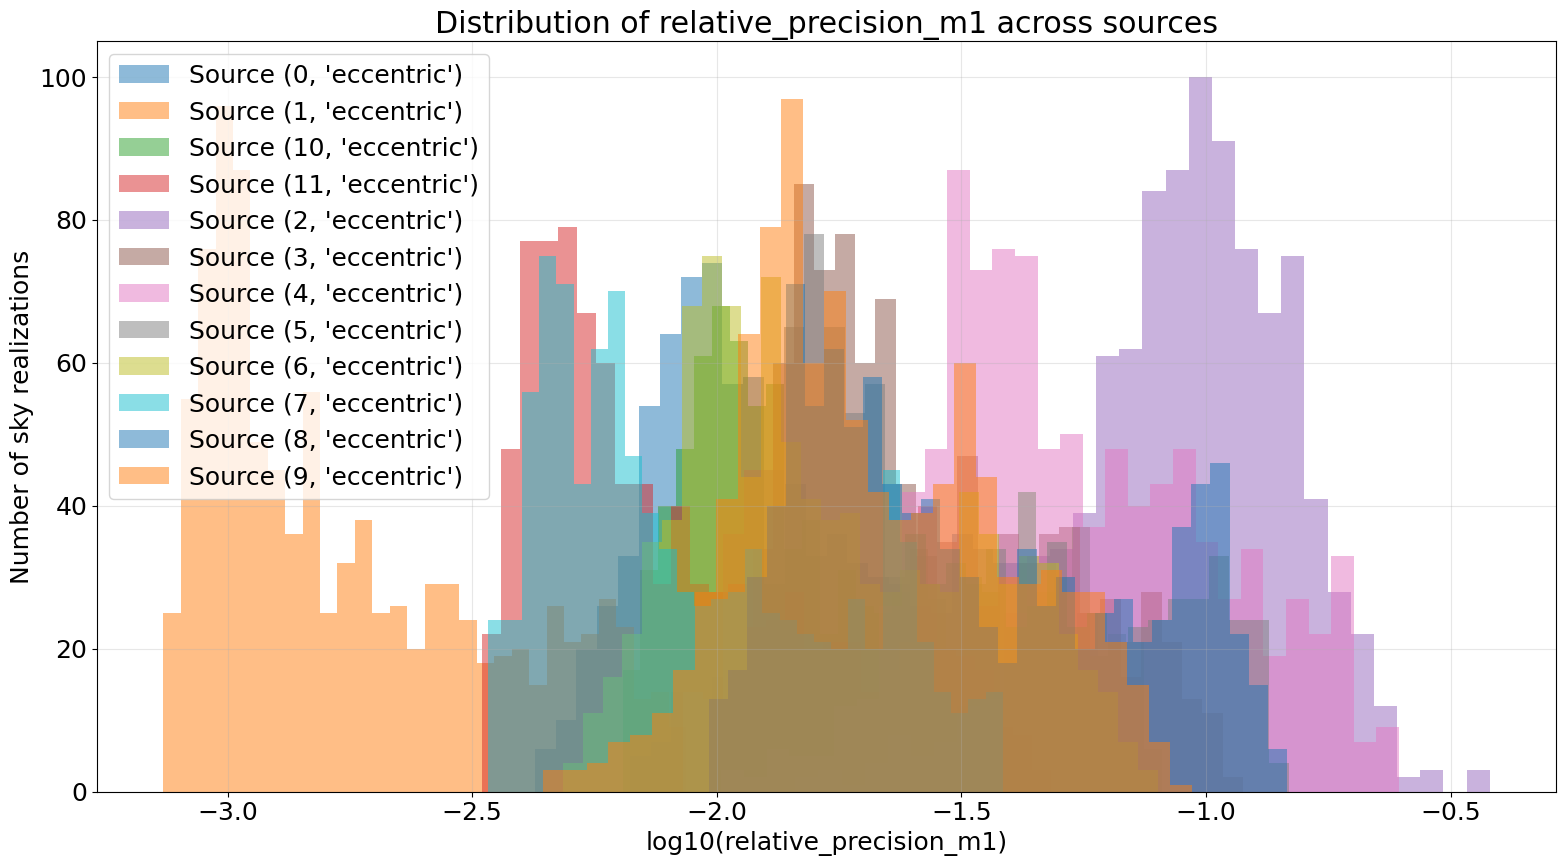

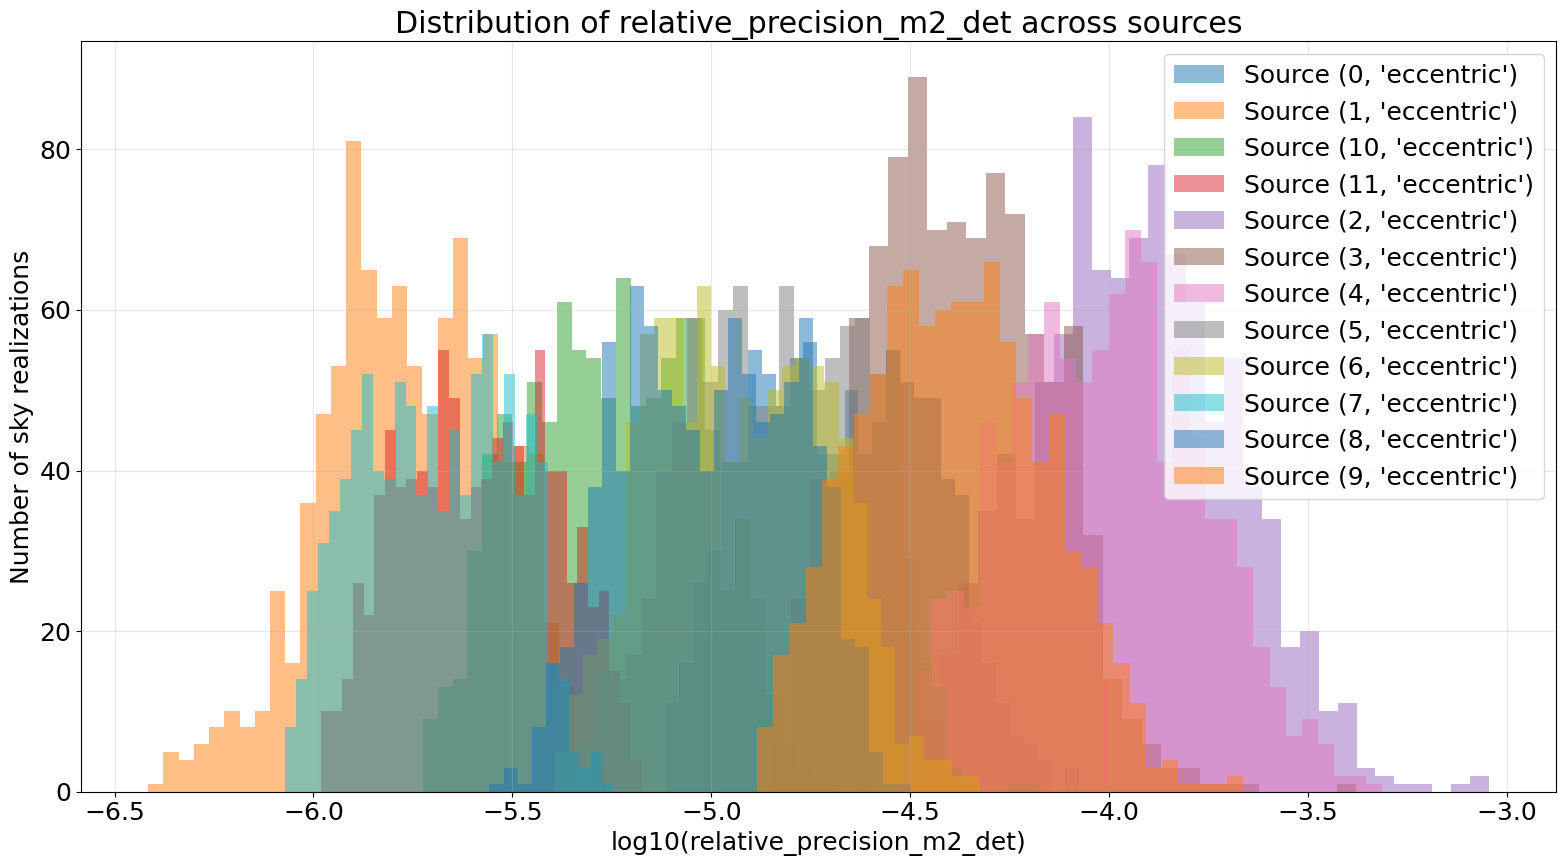

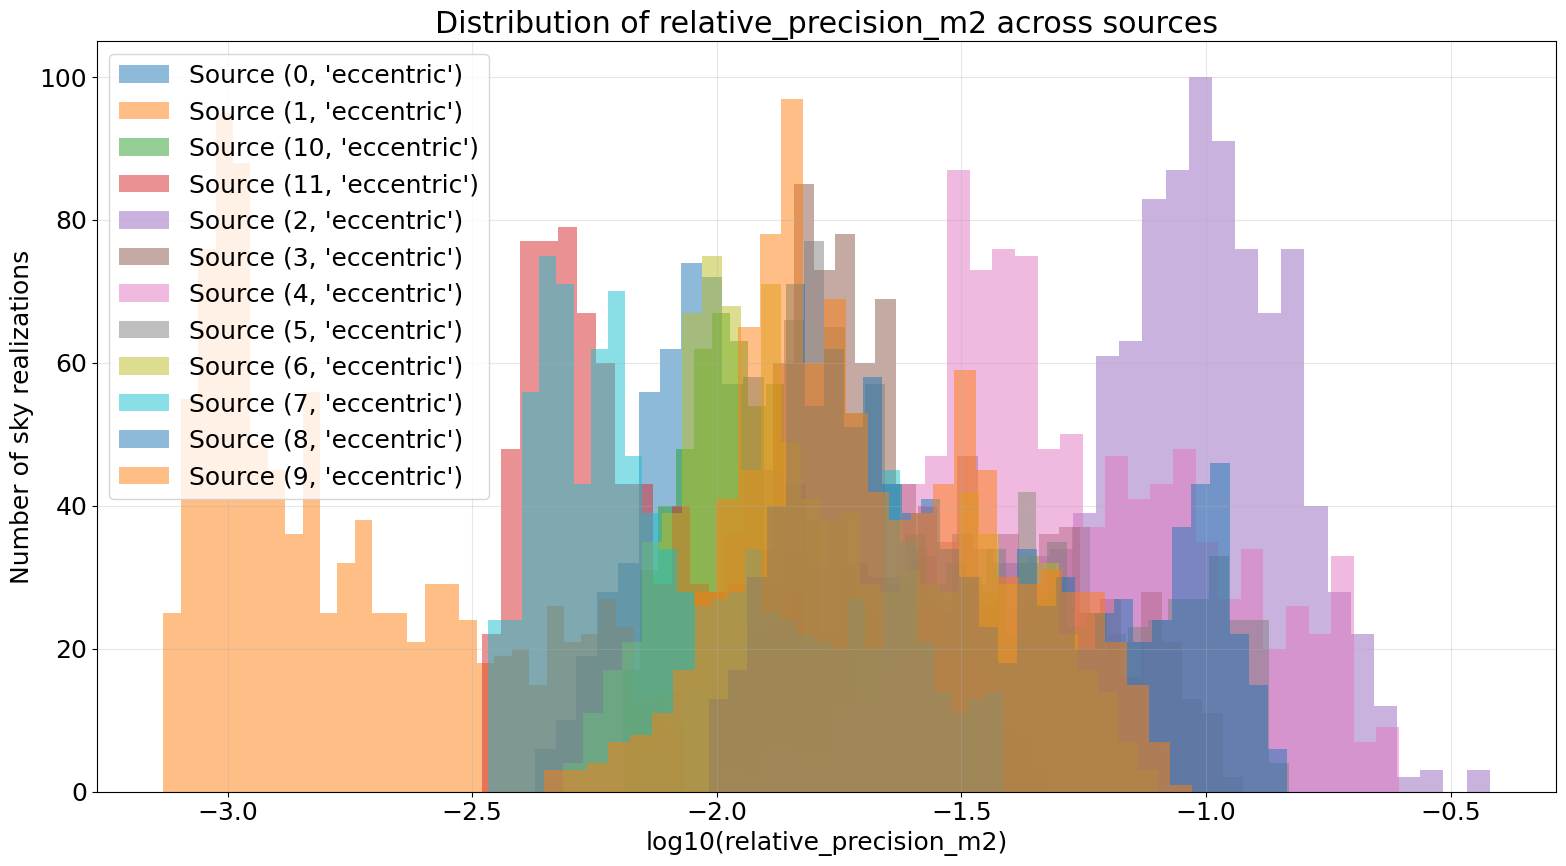

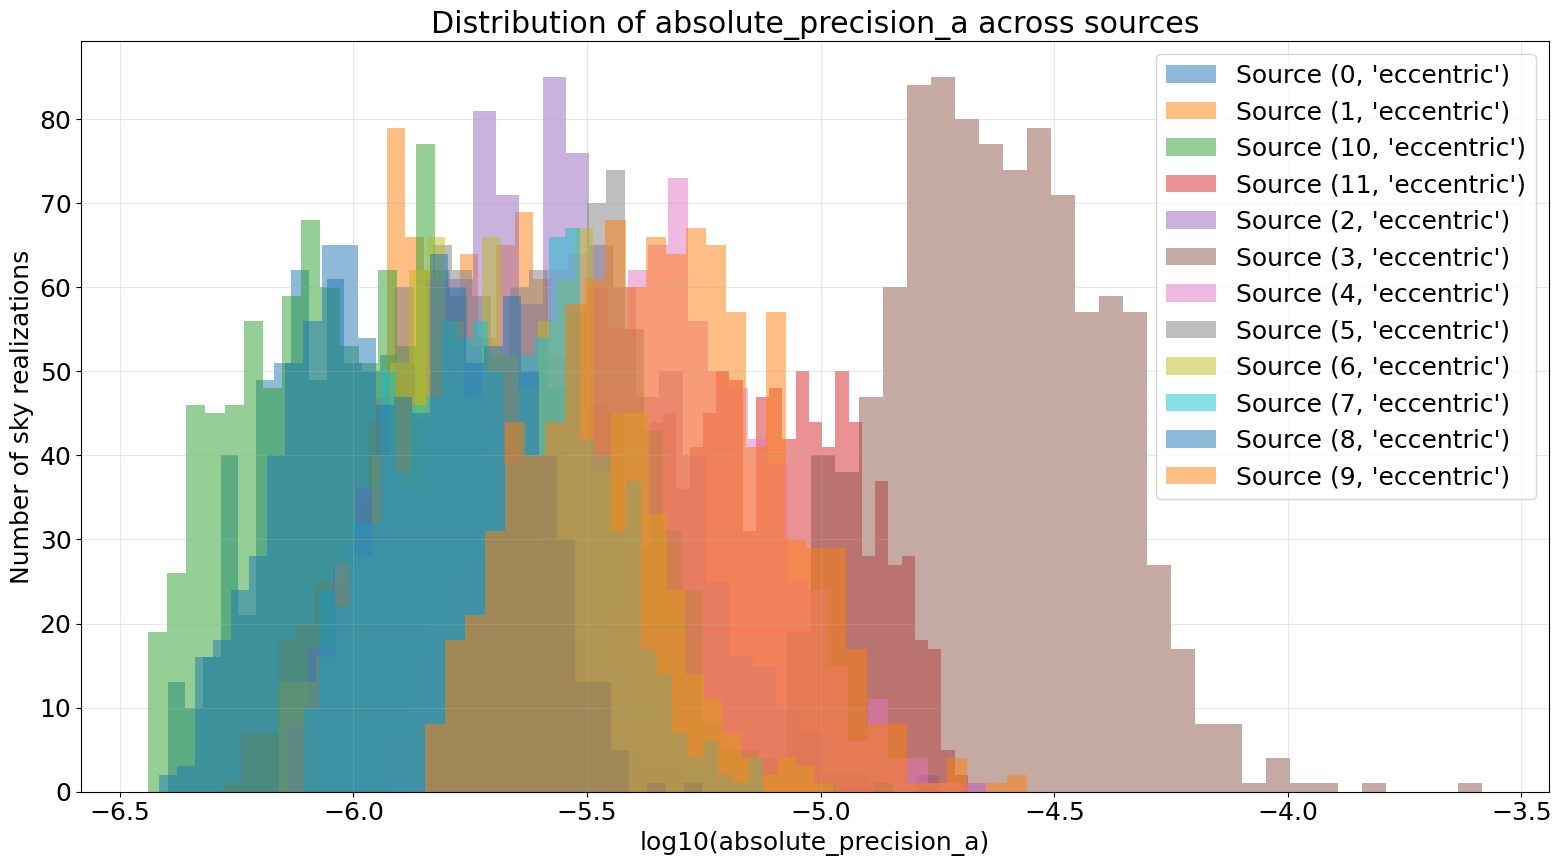

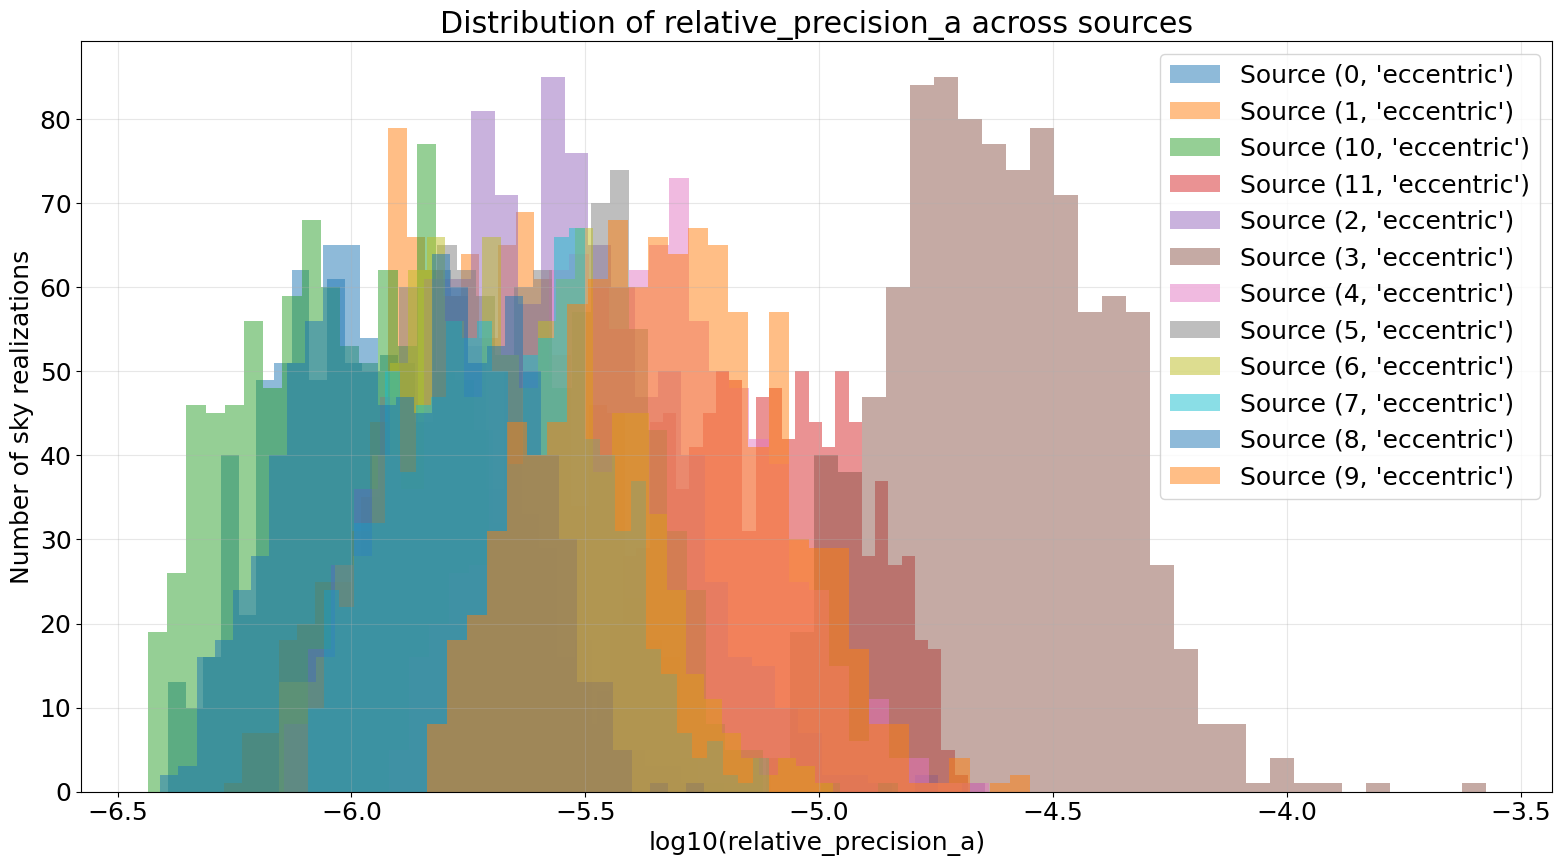

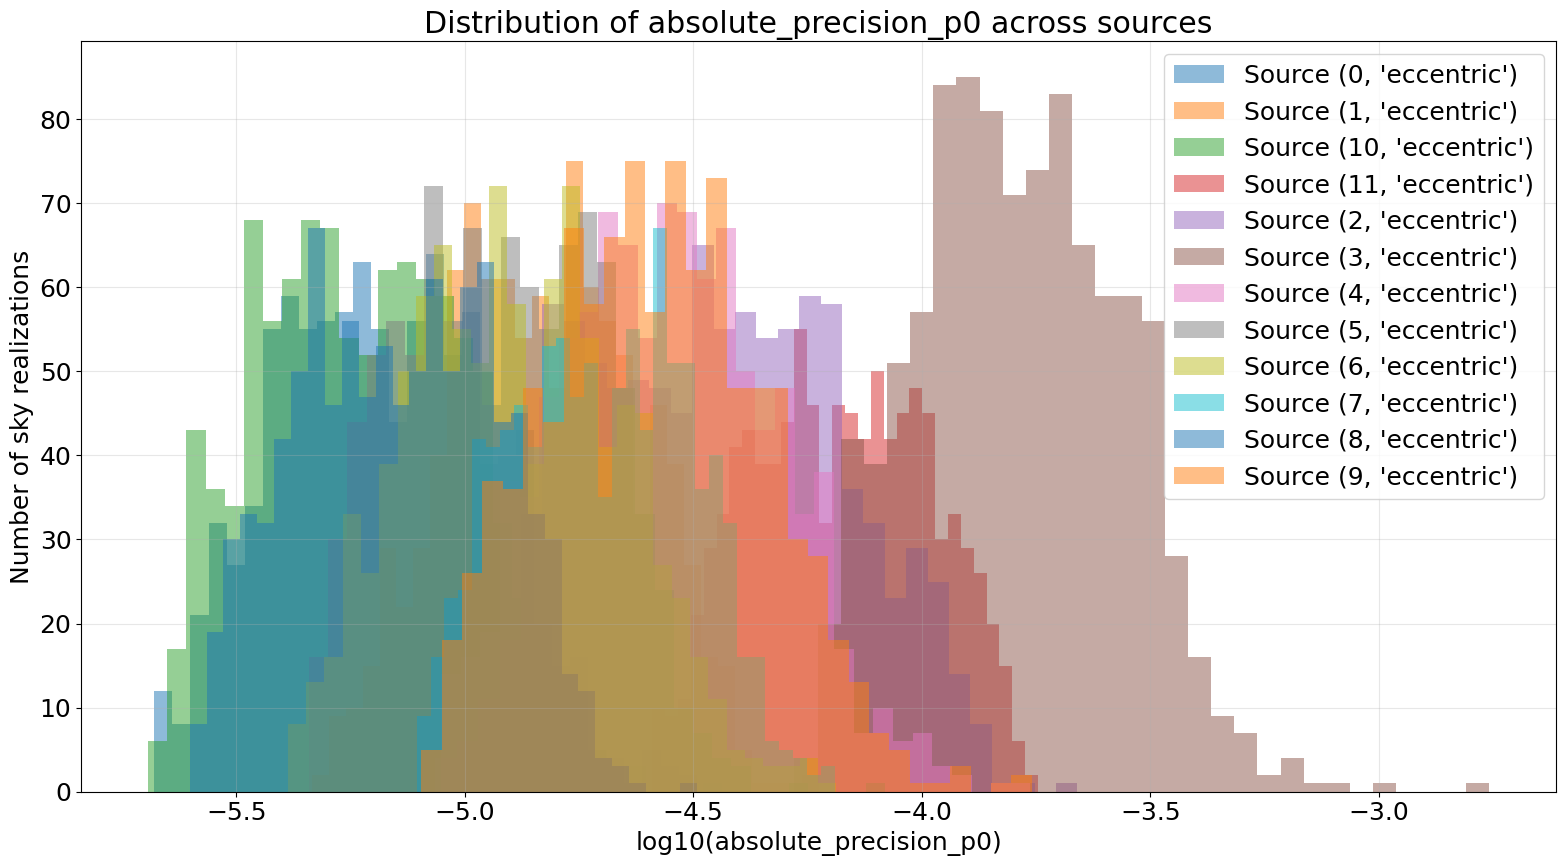

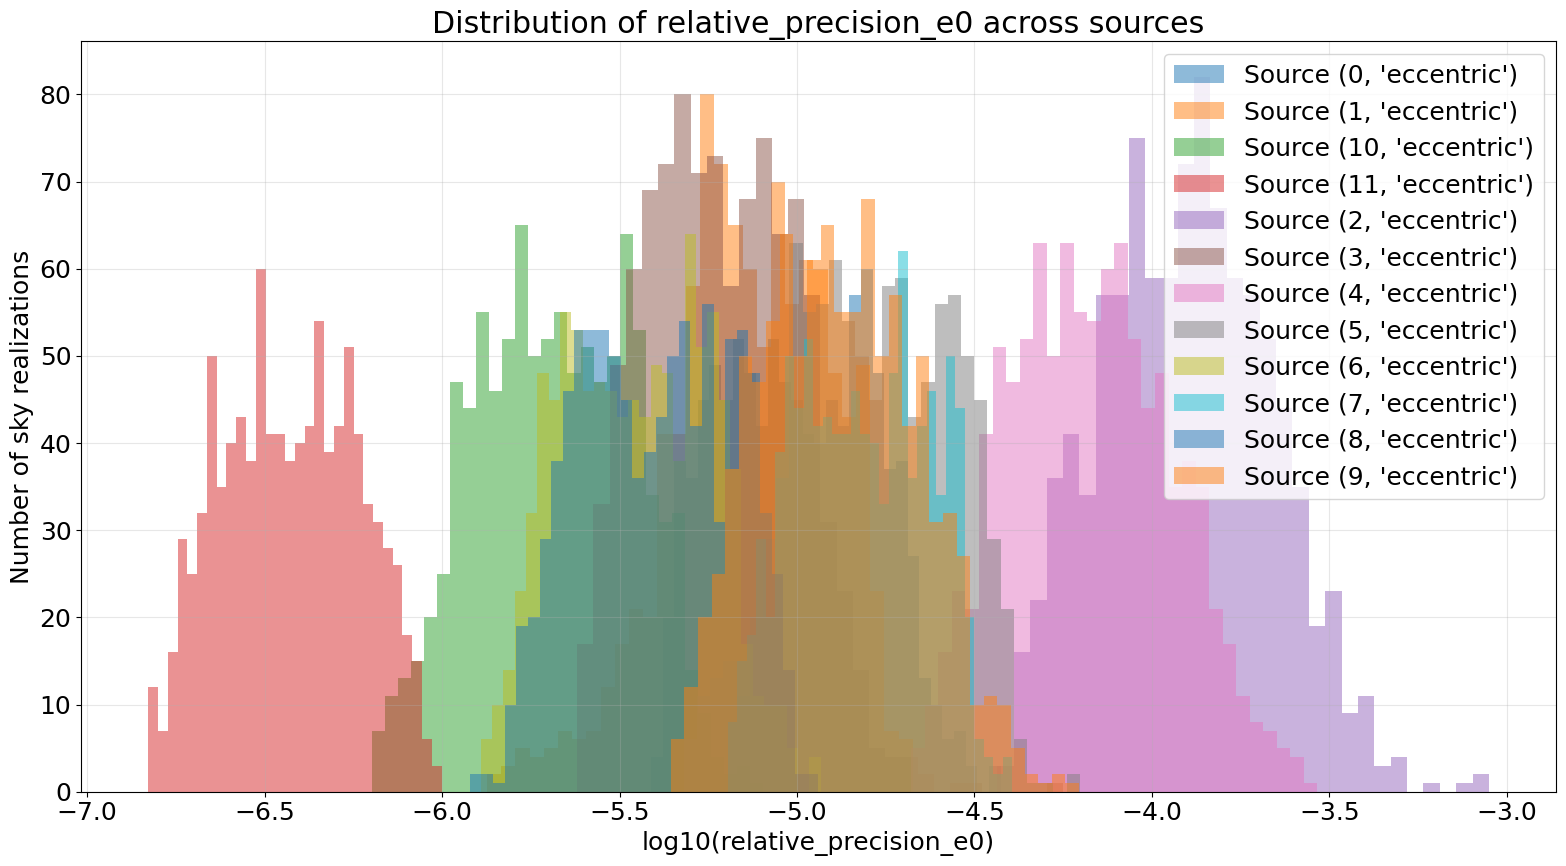

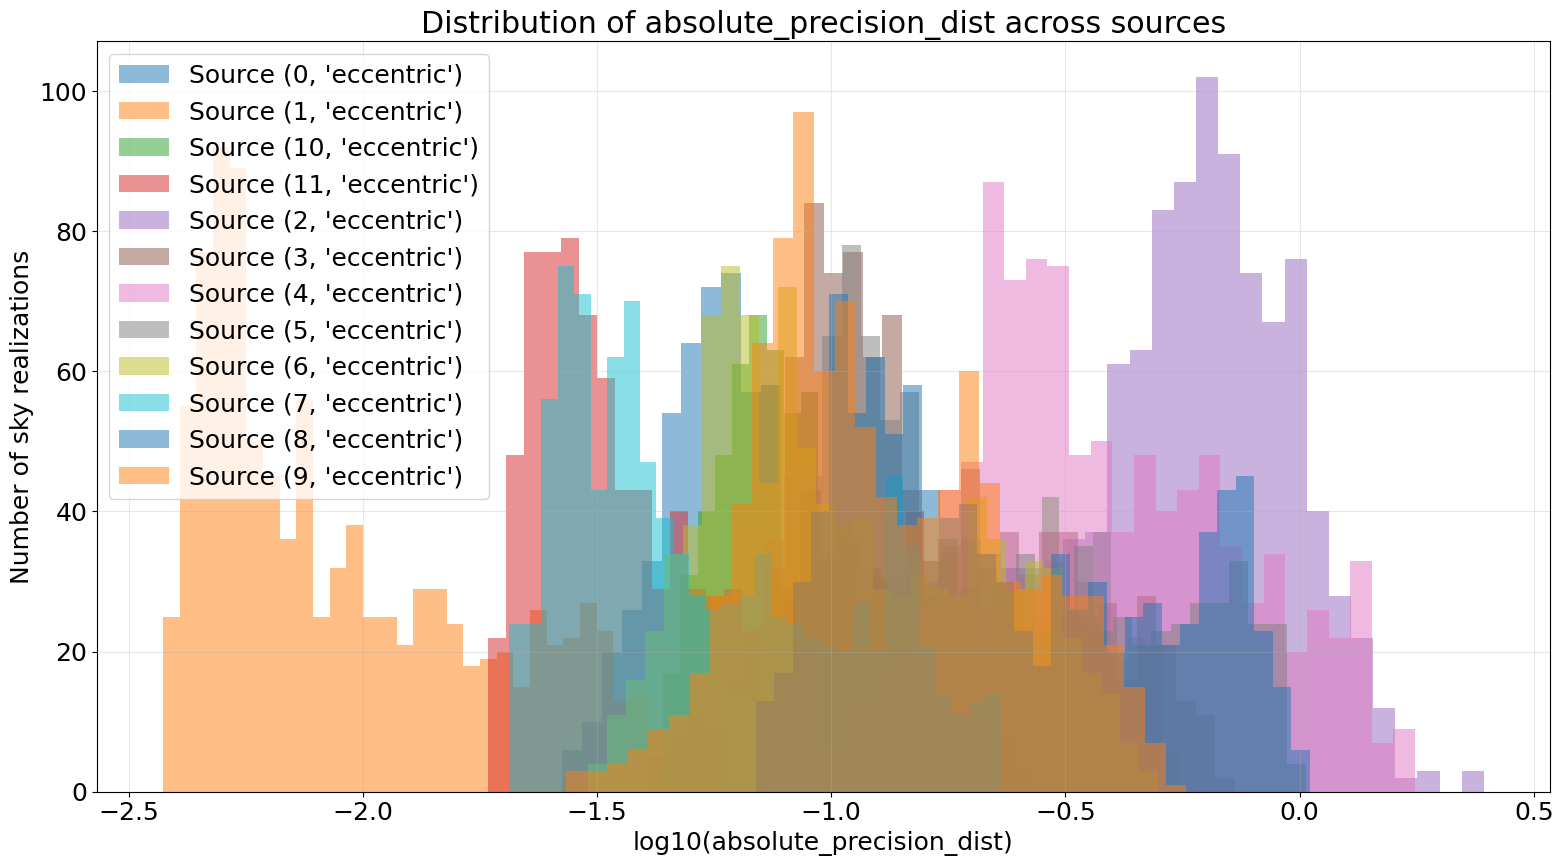

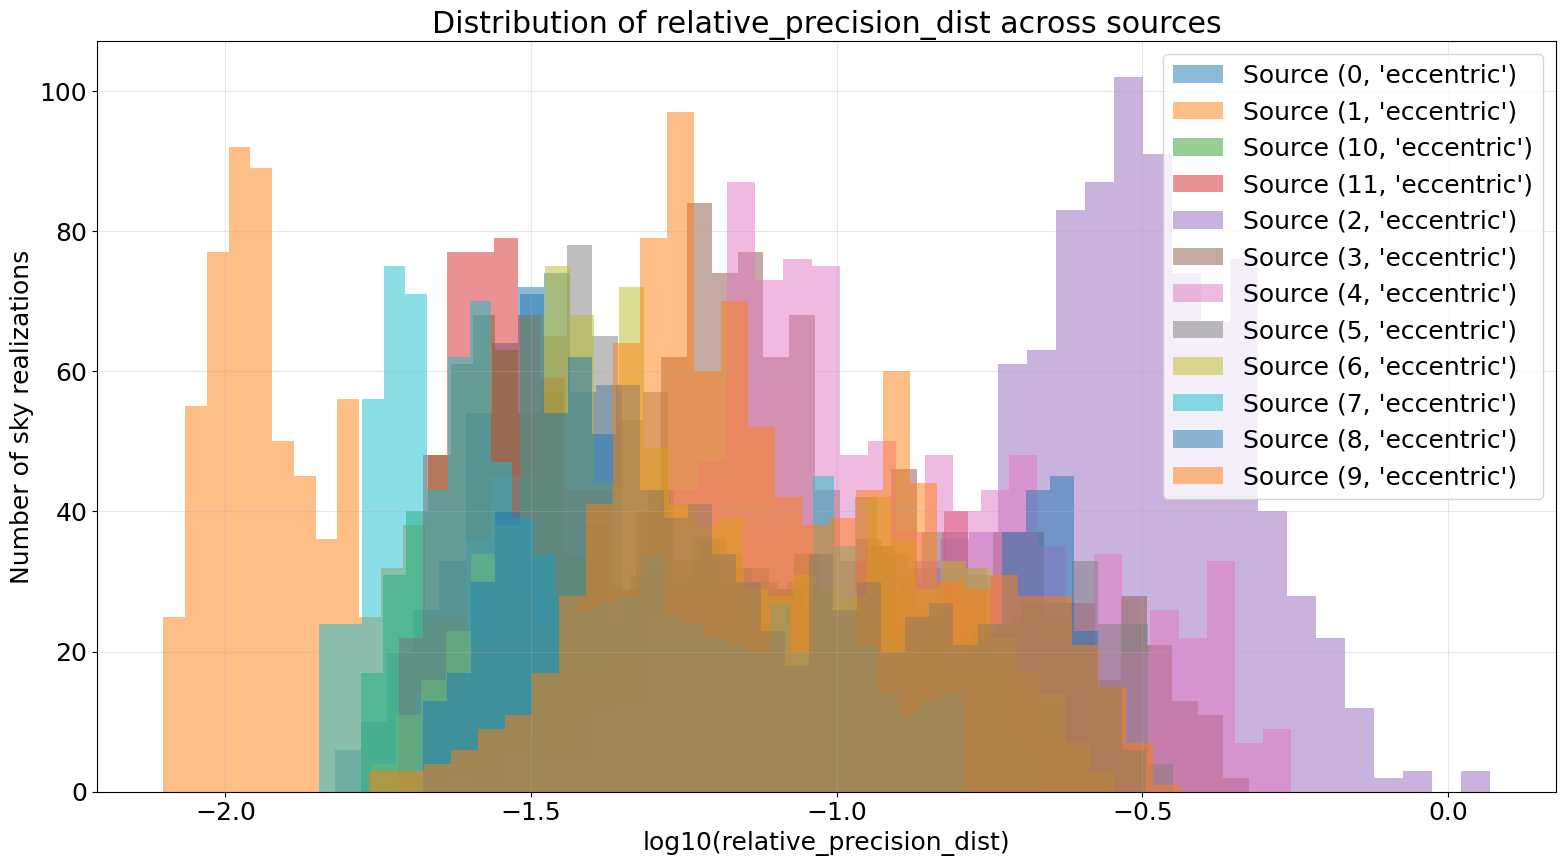

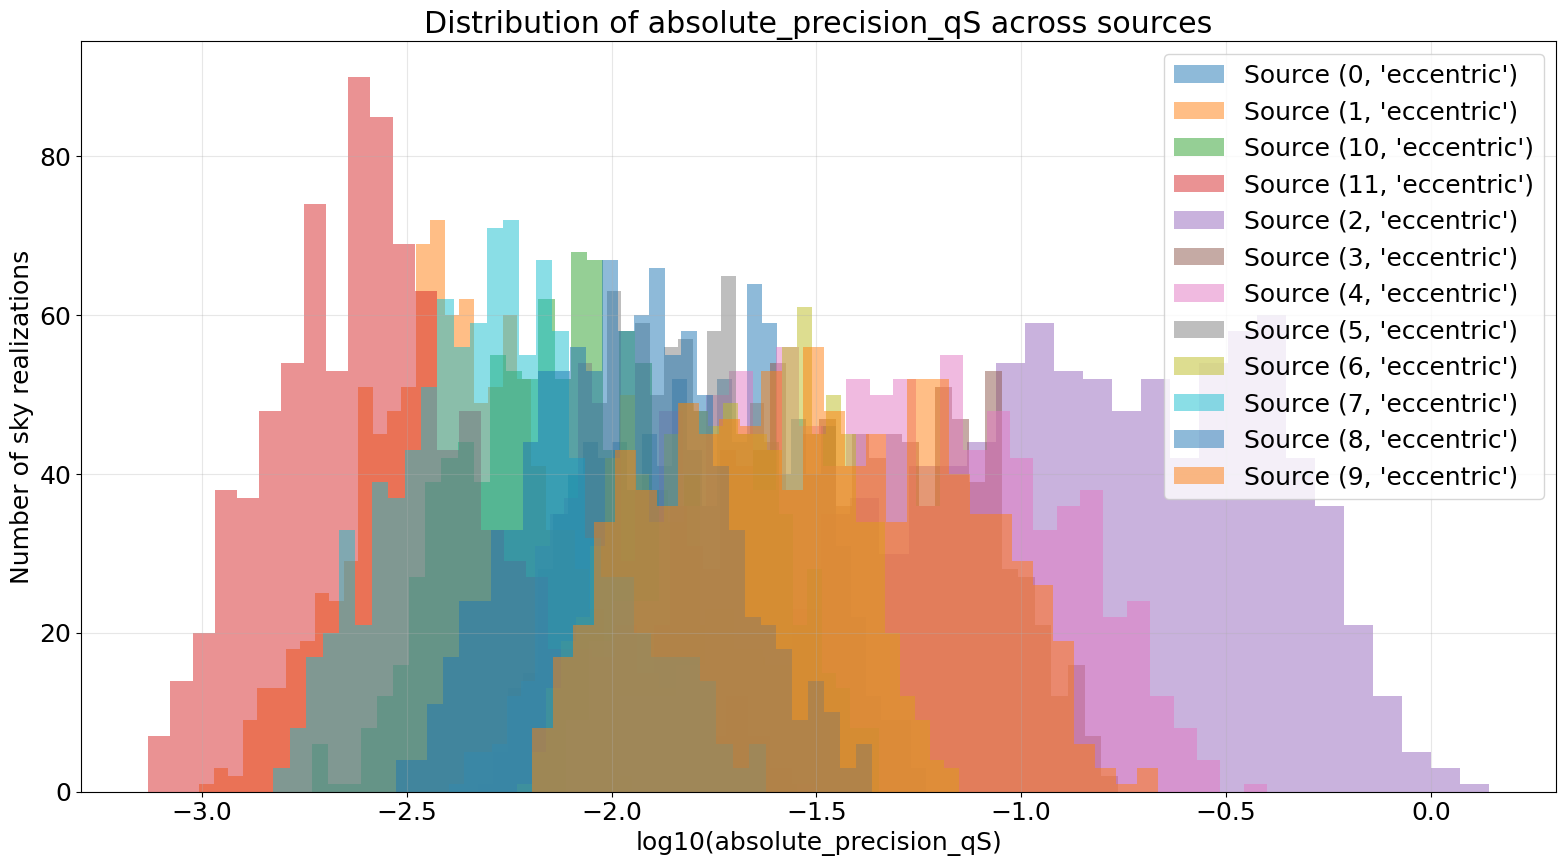

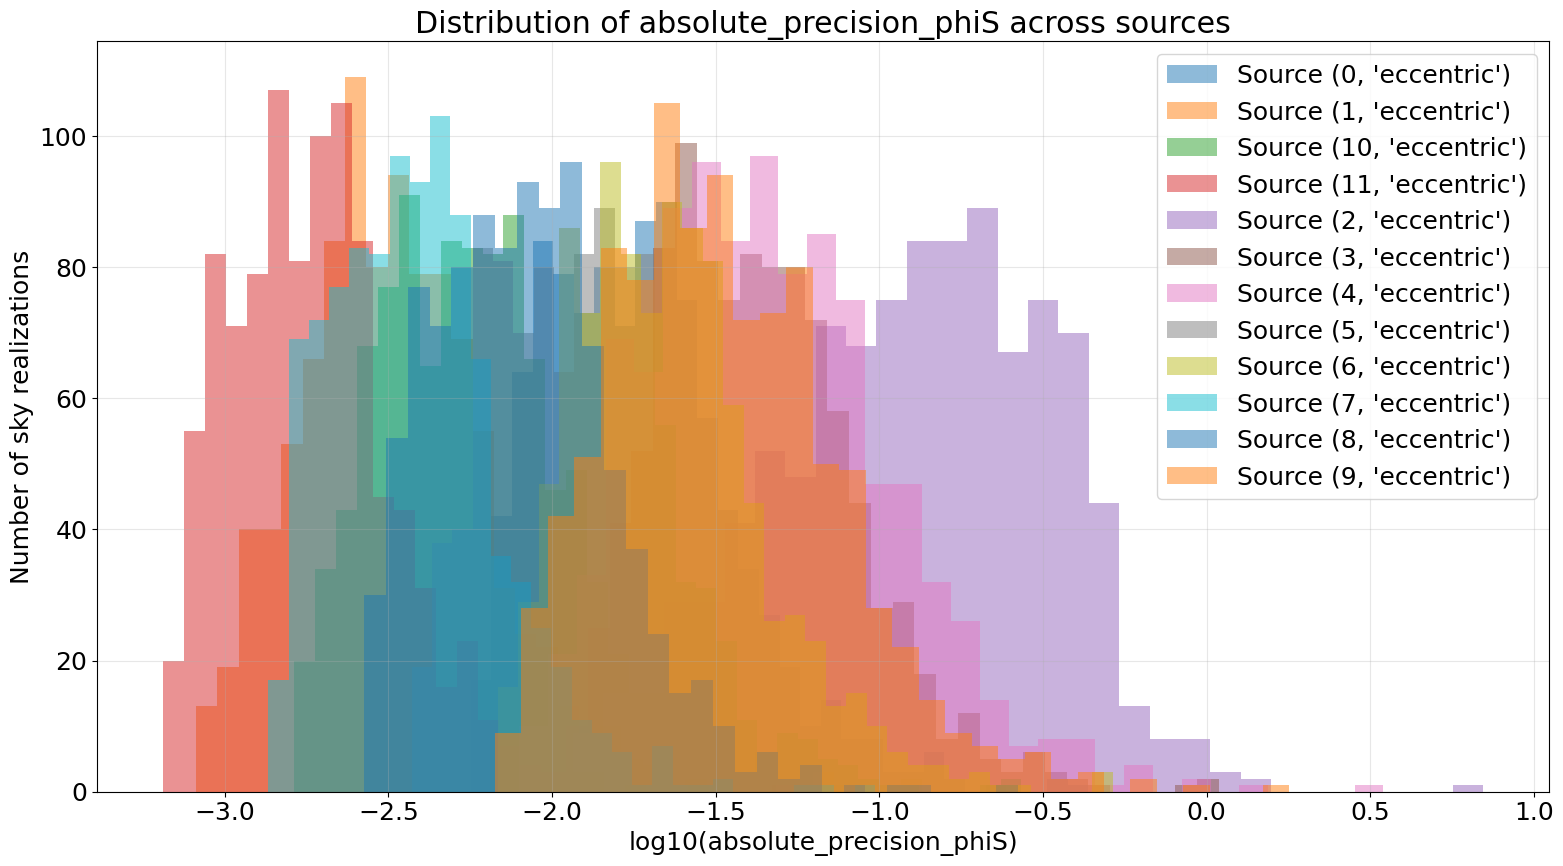

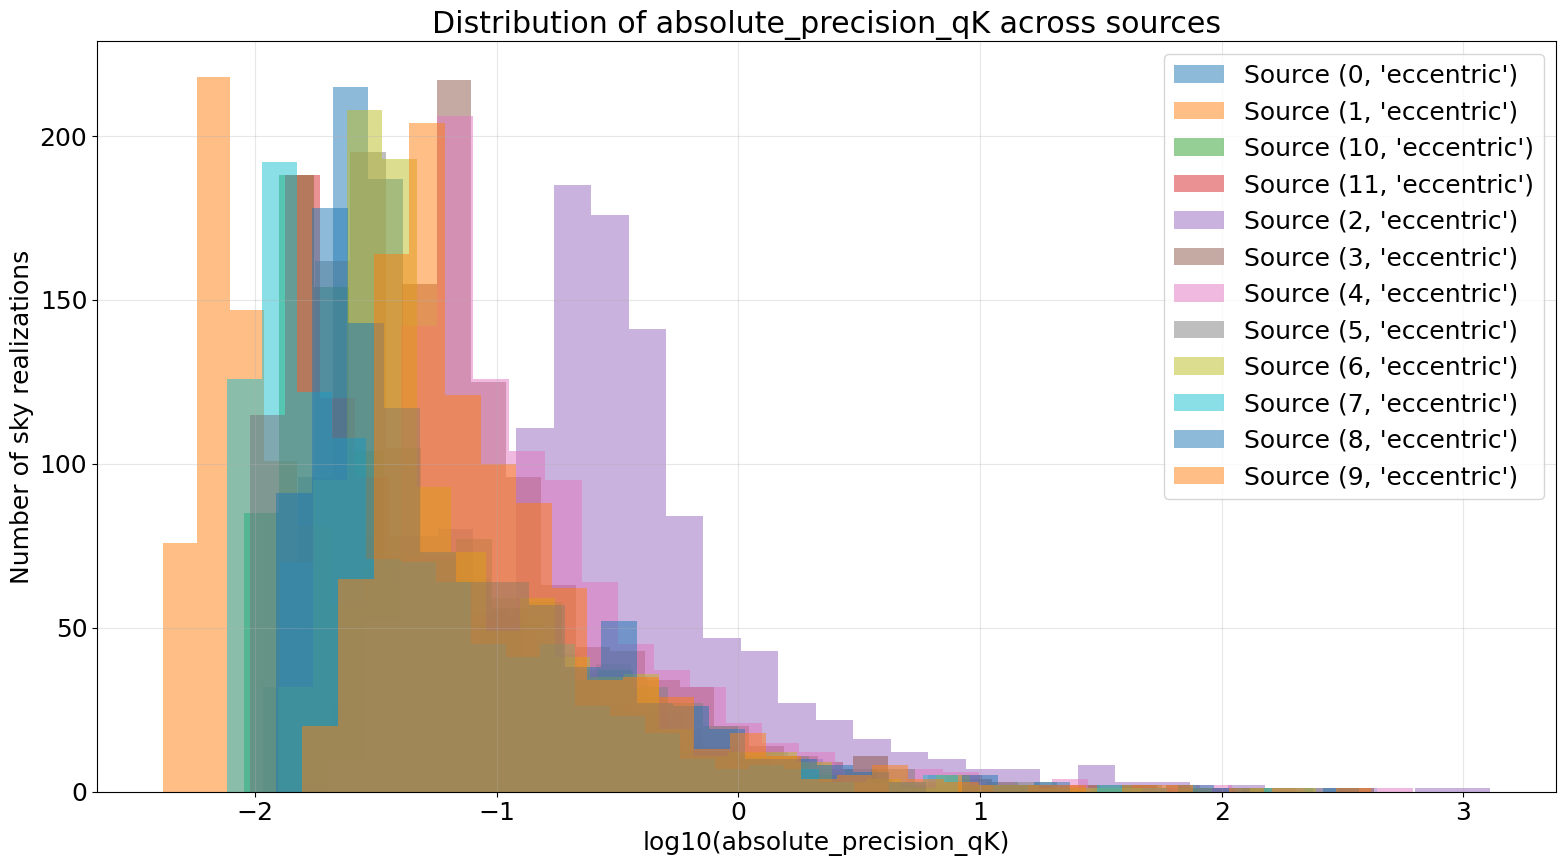

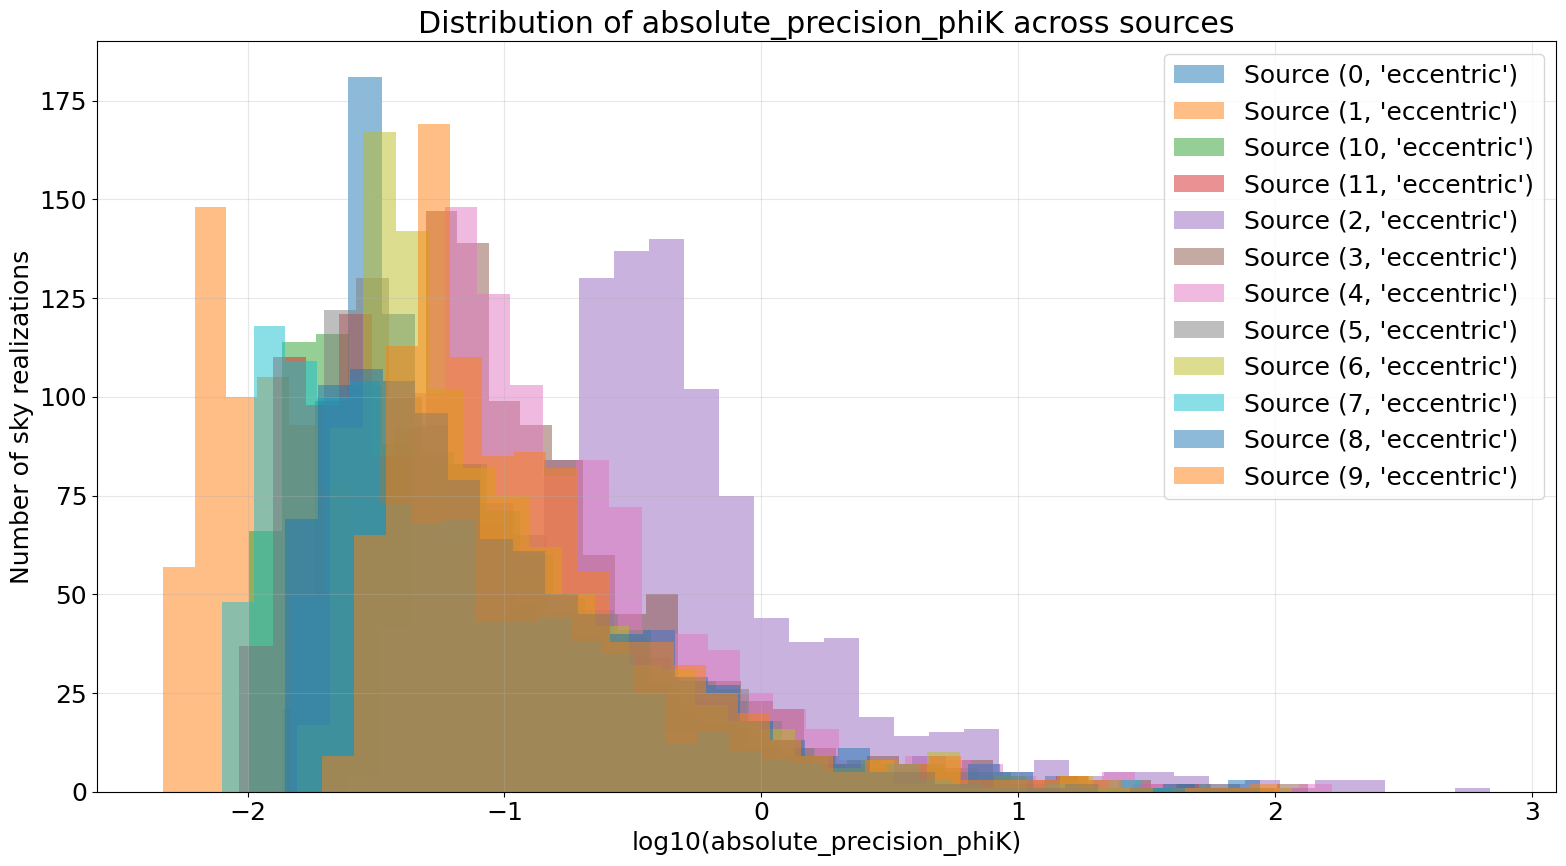

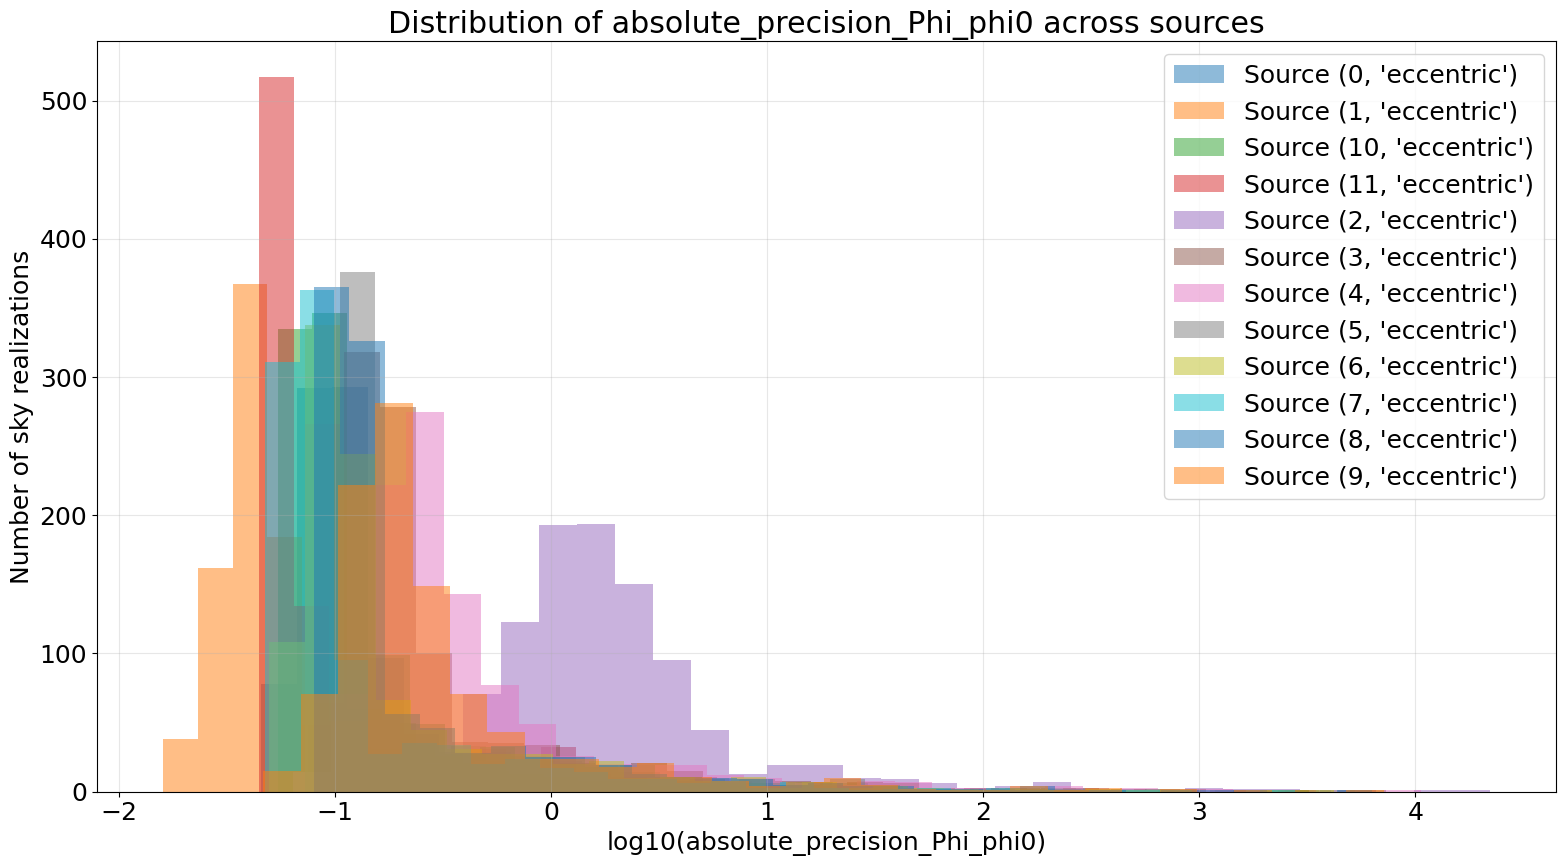

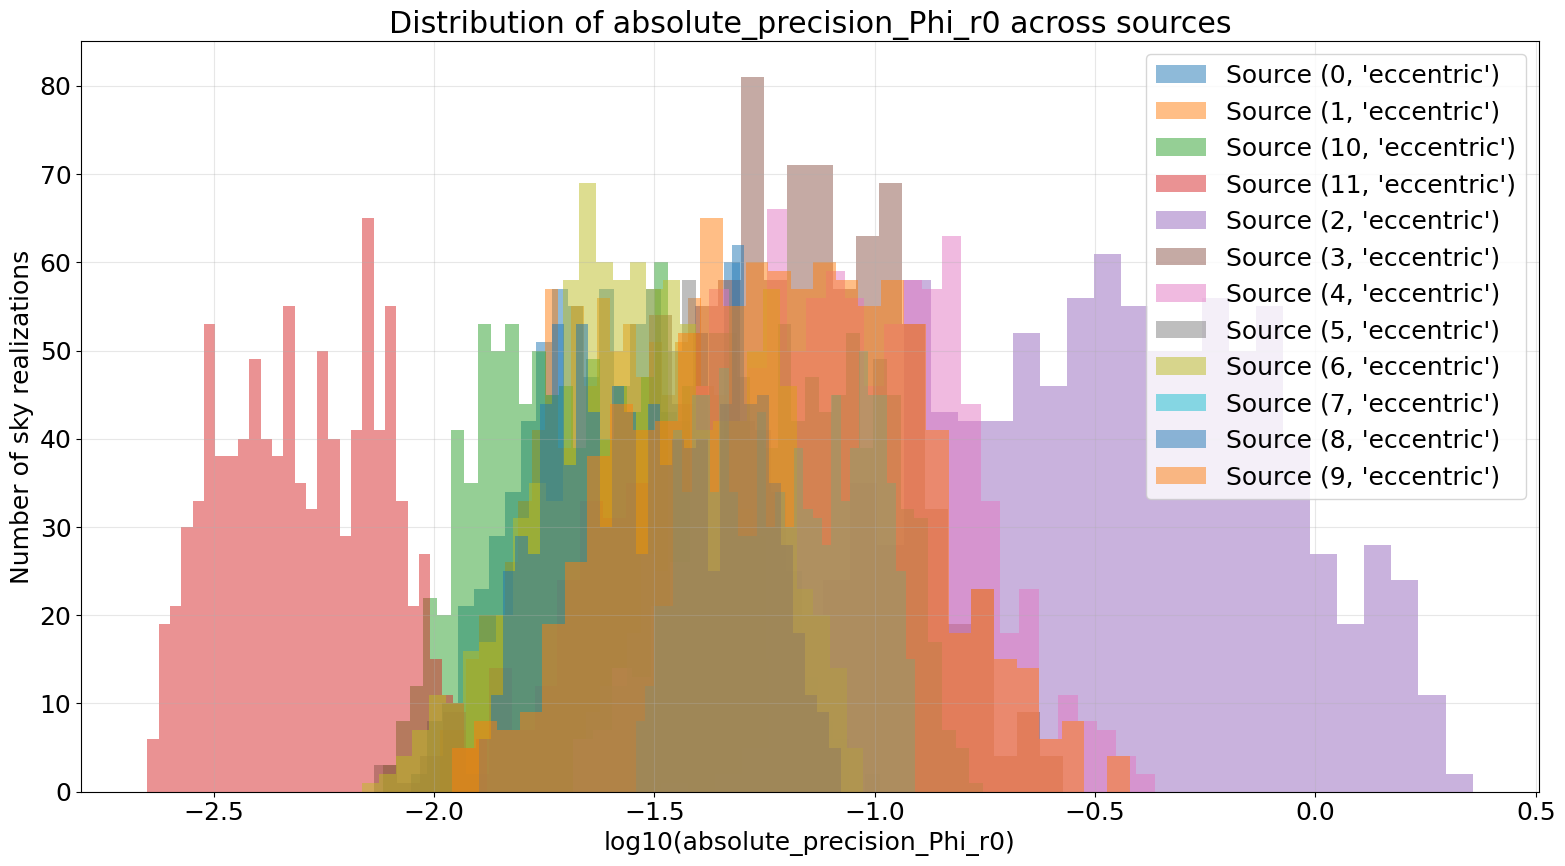

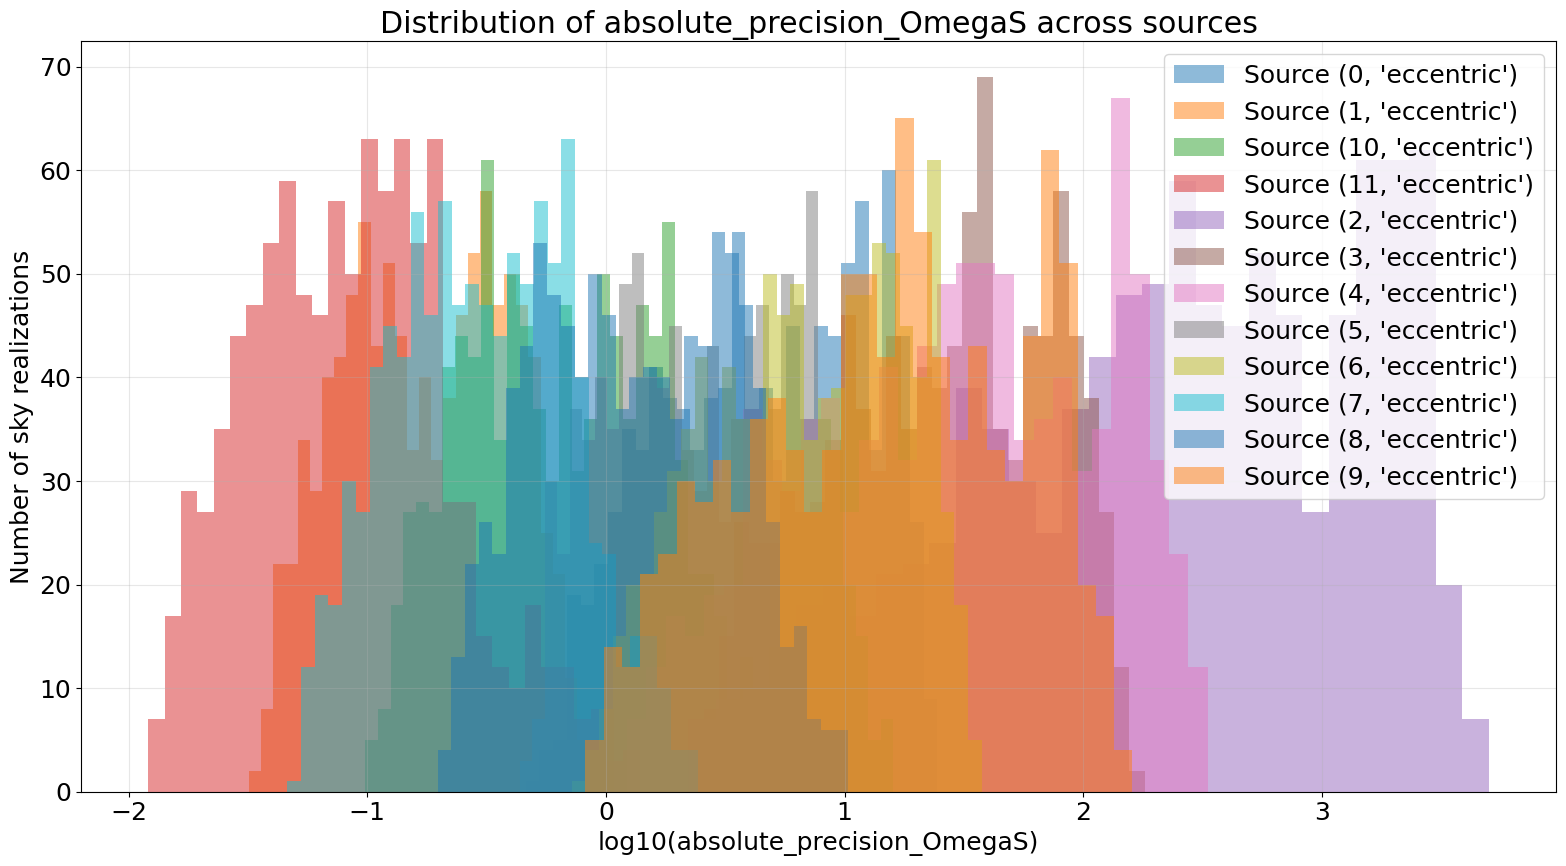

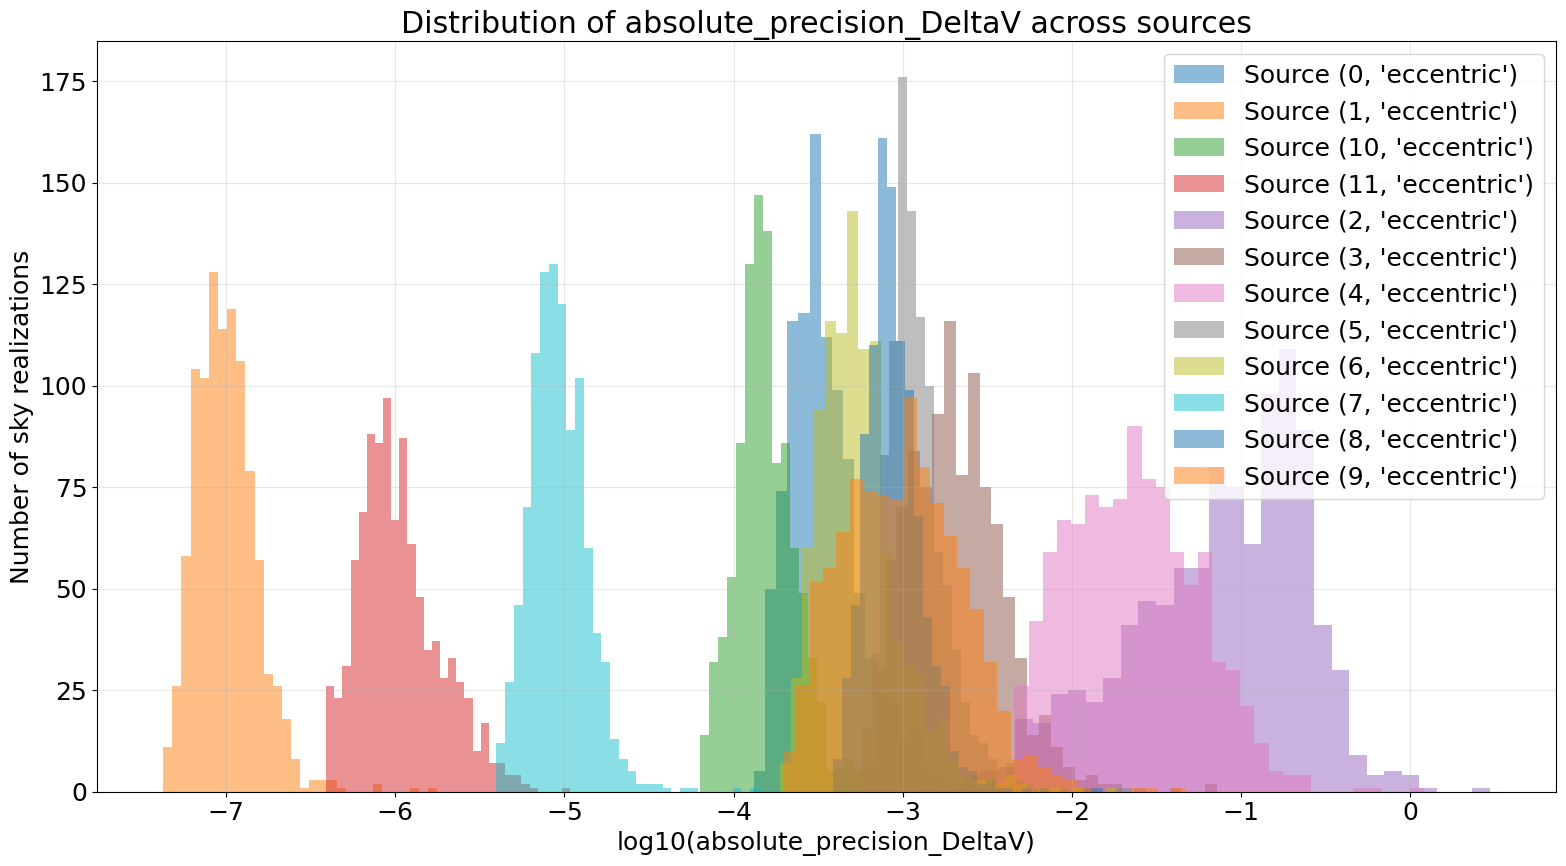

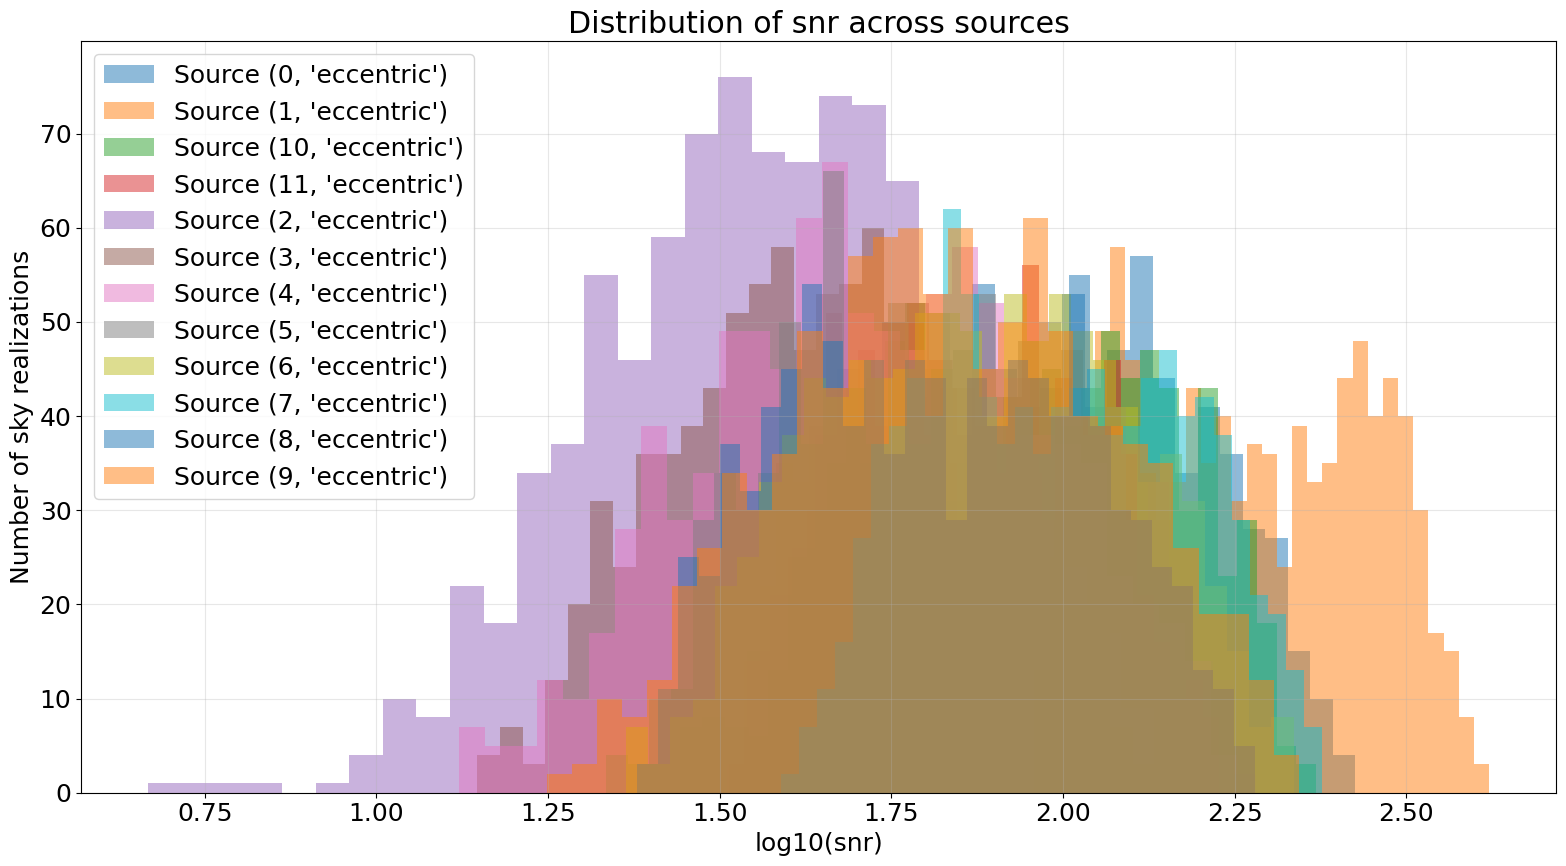

In [24]:
source_keys = list(inference_precision_data.keys())
par_keys = list(inference_precision_data[source_keys[0]].keys())

# per each parameter, plot the distribution of relative precision across sky realizations
for par in par_keys:
    plt.figure()
    for key in source_keys:
        if par in inference_precision_data[key]:
            plt.hist(np.log10(inference_precision_data[key][par]), bins=30, alpha=0.5, label=f'Source {key}')
    plt.xlabel('log10(' + par + ')')
    plt.ylabel("Number of sky realizations")
    plt.legend()
    plt.title(f'Distribution of {par} across sources')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

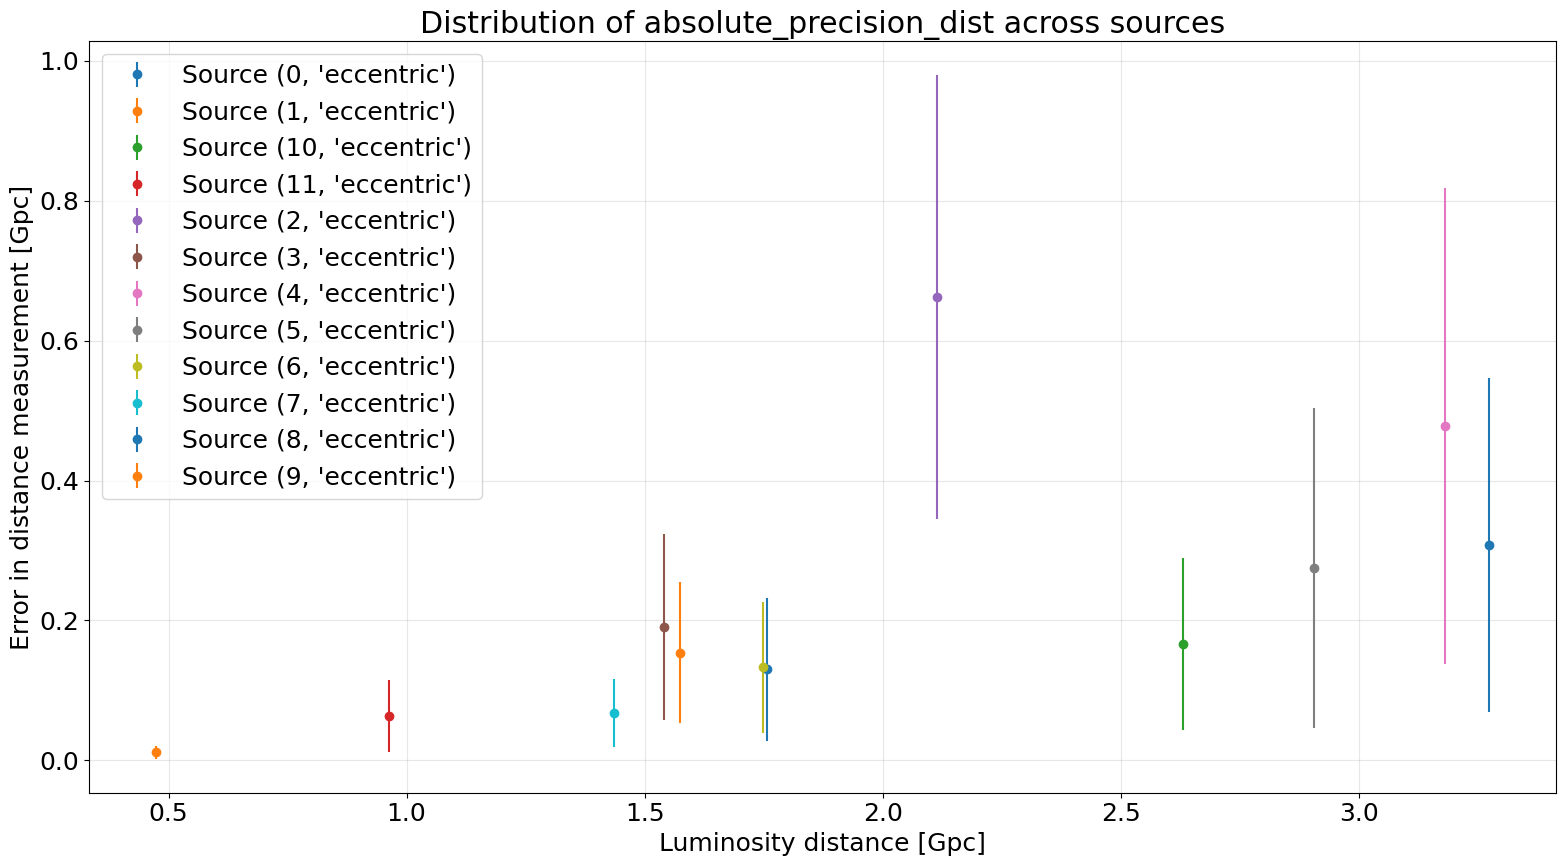

In [25]:
source_keys = list(inference_precision_data.keys())
par_keys = list(inference_precision_data[source_keys[0]].keys())

# per each parameter, plot the distribution of relative precision across sky realizations
plt.figure()
for par in ['absolute_precision_dist']:
    
    for key in source_keys:
        mean_par = np.mean(inference_precision_data[key][par])
        std_par = np.std(inference_precision_data[key][par])
        plt.errorbar(inference_metadata[key]['dist'], mean_par, std_par, fmt='o', label=f'Source {key}')
        
    plt.xlabel('Luminosity distance [Gpc]')
    plt.ylabel("Error in distance measurement [Gpc]")
    plt.legend()
    plt.title(f'Distribution of {par} across sources')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
plt.show()

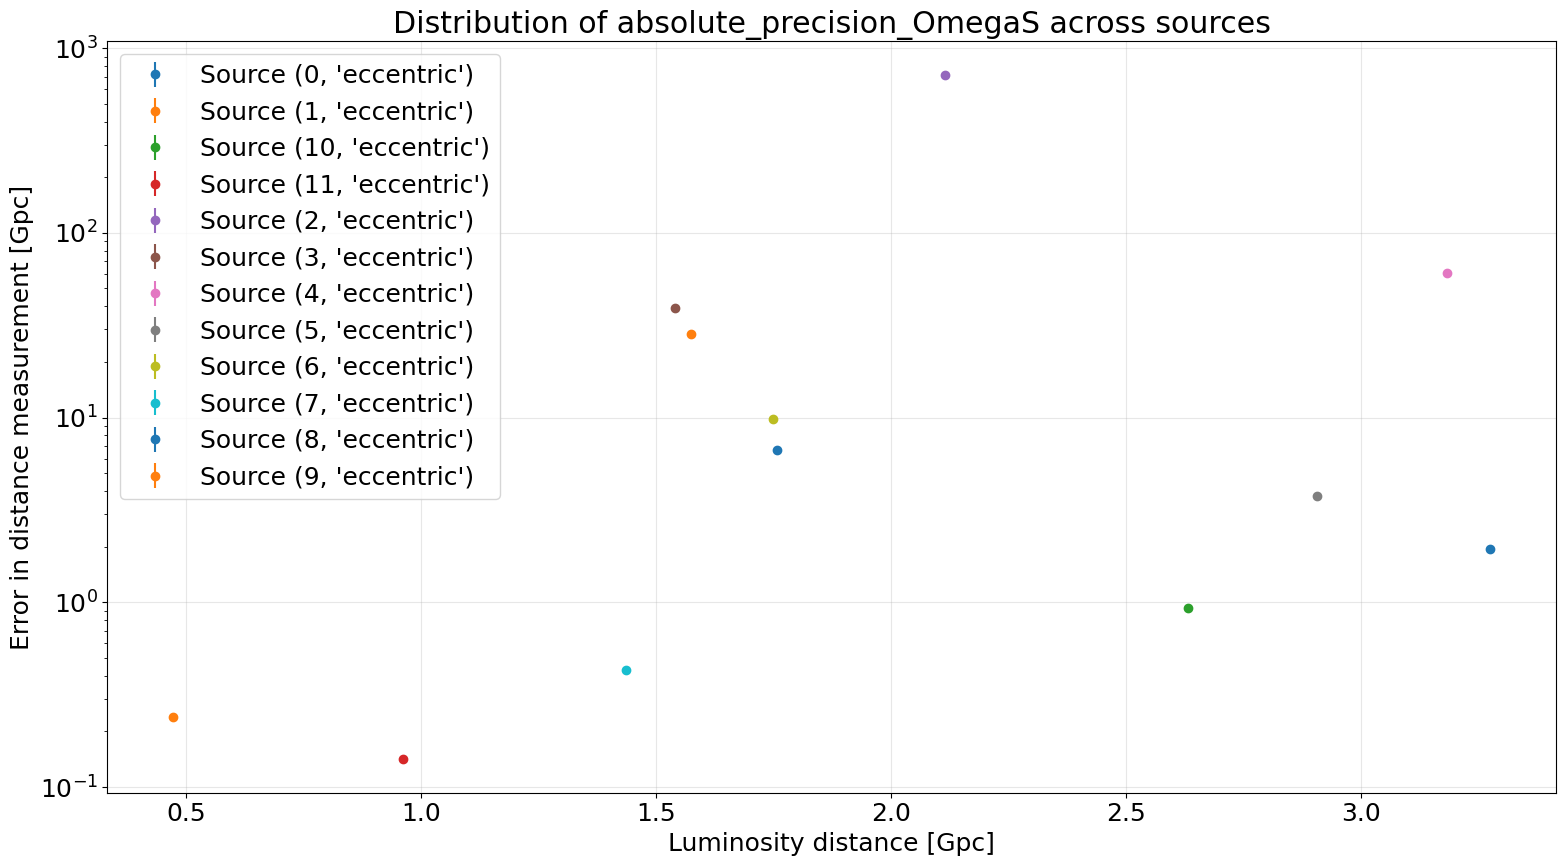

In [26]:
source_keys = list(inference_precision_data.keys())
par_keys = list(inference_precision_data[source_keys[0]].keys())

# per each parameter, plot the distribution of relative precision across sky realizations
plt.figure()
for par in ['absolute_precision_OmegaS']:
    
    for key in source_keys:
        mean_par = np.mean(inference_precision_data[key][par])
        std_par = np.std(inference_precision_data[key][par]) * 0.0
        plt.errorbar(inference_metadata[key]['dist'], mean_par, std_par, fmt='o', label=f'Source {key}')
    
    plt.semilogy()
    plt.xlabel('Luminosity distance [Gpc]')
    plt.ylabel("Error in distance measurement [Gpc]")
    plt.legend()
    plt.title(f'Distribution of {par} across sources')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
plt.show()

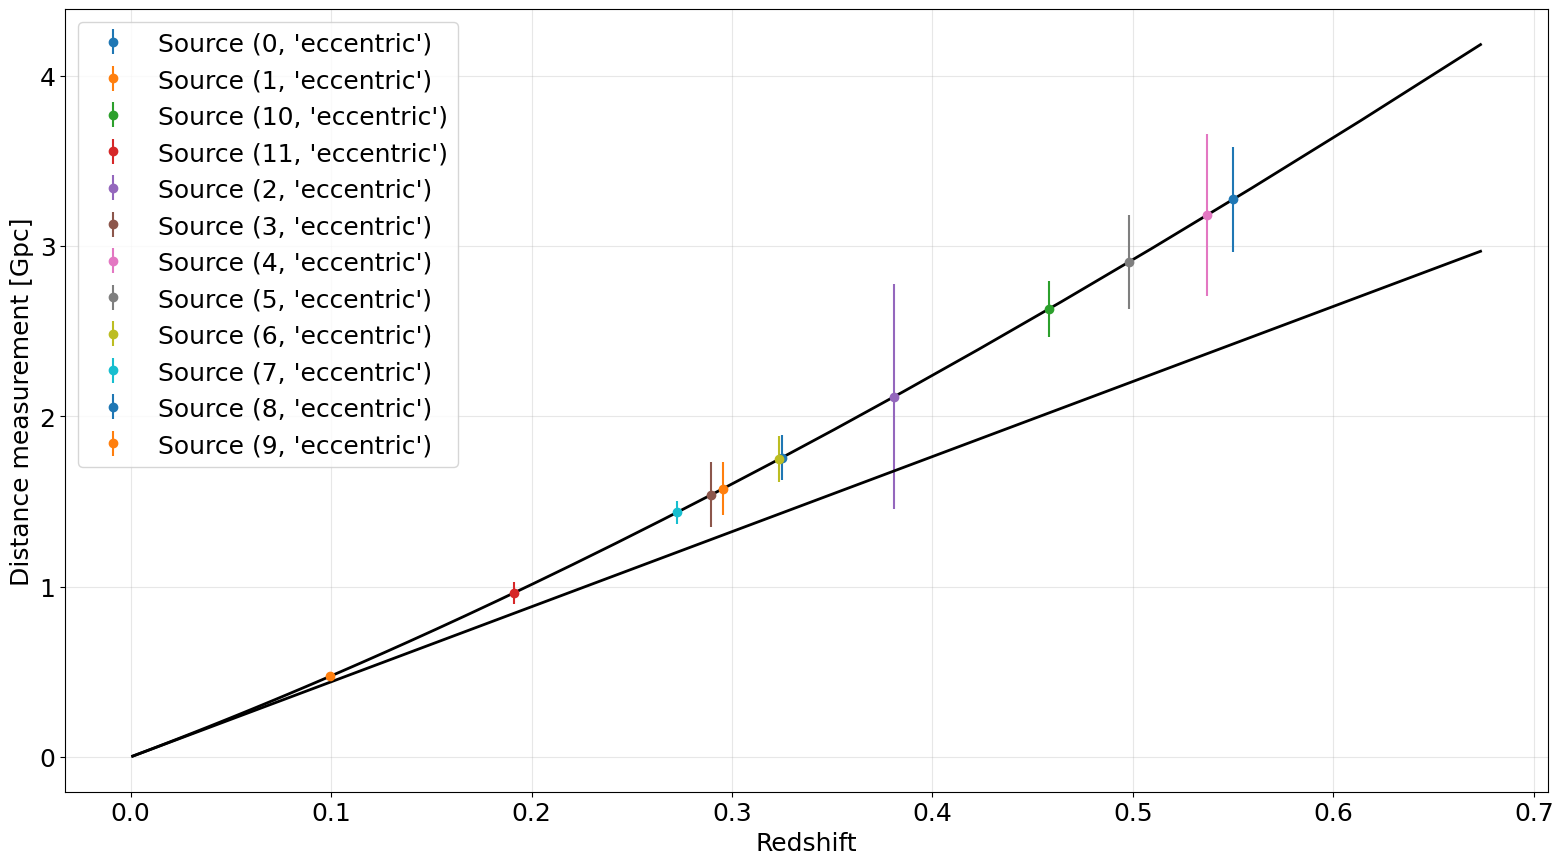

In [27]:
source_keys = list(inference_precision_data.keys())
par_keys = list(inference_precision_data[source_keys[0]].keys())
data_cosmo = []
# per each parameter, plot the distribution of relative precision across sky realizations
plt.figure()
for par in ['absolute_precision_dist']:
    
    for key in source_keys:
        mean_par = np.mean(inference_precision_data[key][par])
        std_par = np.std(inference_precision_data[key][par])
        plt.errorbar(inference_metadata[key]['redshift'], inference_metadata[key]['dist'], mean_par, fmt='o', label=f'Source {key}')
        data_cosmo.append([inference_metadata[key]['redshift'], inference_metadata[key]['dist'], mean_par])
        
mask_z = z_vec < 0.7
h = 0.68
d_linear = 2.998 * z_vec[mask_z] / h
plt.plot(z_vec[mask_z], d_vec[mask_z],'k', linewidth=2)
plt.plot(z_vec[mask_z], d_linear,'k', linewidth=2)
plt.xlabel('Redshift')
plt.ylabel("Distance measurement [Gpc]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
from scipy.optimize import minimize
from astropy.cosmology import FlatLambdaCDM

def fit_flatlambdacdm(redshifts, distances, distance_errors, h0_init=70, om0_init=0.3):
    """
    Fit a FlatLambdaCDM cosmology to (redshift, distance, error) data.
    Returns best-fit H0 and Om0.
    """
    def chi2(params):
        H0, Om0 = params
        cosmo = FlatLambdaCDM(H0=H0, Om0=Om0)
        model_dist = cosmo.luminosity_distance(redshifts).value  # in Mpc
        # Convert observed distances to Mpc if needed
        obs_dist = np.array(distances)
        obs_err = np.array(distance_errors)
        return np.sum(((obs_dist - model_dist) / obs_err) ** 2)

    result = minimize(chi2, [h0_init, om0_init], bounds=[(50, 90), (0.1, 0.5)])
    best_H0, best_Om0 = result.x
    return best_H0, best_Om0

redshifts, distances, sigma_d = np.asarray(data_cosmo).T
best_H0, best_Om0 = fit_flatlambdacdm(redshifts, distances*1e3, sigma_d*1e3)
print(f"Best-fit H0: {best_H0:.2f} km/s/Mpc, Omega_m: {best_Om0:.3f}")

Best-fit H0: 67.66 km/s/Mpc, Omega_m: 0.311


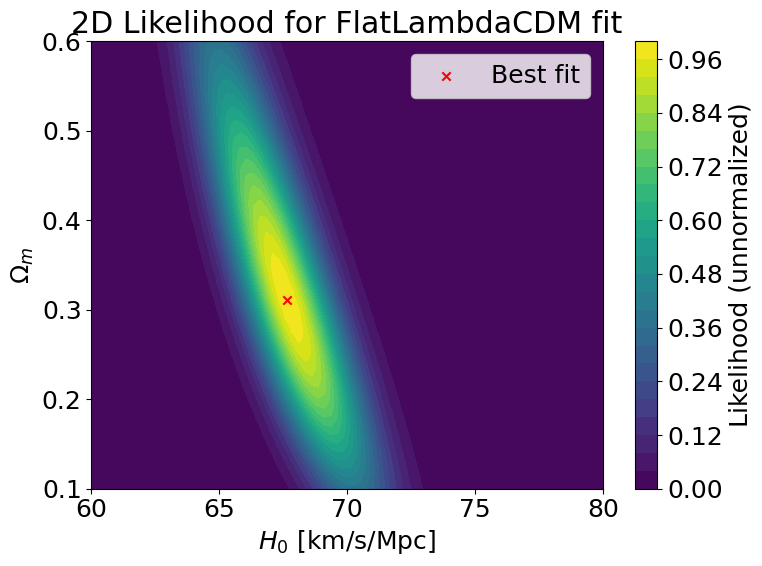

In [29]:
# Define grid for H0 and Om0
H0_grid = np.linspace(60, 80, 80)
Om0_grid = np.linspace(0.1, 0.6, 80)

# Compute chi2 on the grid
chi2_grid = np.zeros((len(H0_grid), len(Om0_grid)))
for i, H0 in enumerate(H0_grid):
    for j, Om0 in enumerate(Om0_grid):
        cosmo = FlatLambdaCDM(H0=H0, Om0=Om0)
        model_dist = cosmo.luminosity_distance(redshifts).value
        chi2_grid[i, j] = np.sum(((distances*1e3 - model_dist) / (sigma_d*1e3)) ** 2)

# Convert chi2 to likelihood (unnormalized)
likelihood = np.exp(-0.5 * (chi2_grid - np.nanmin(chi2_grid)))

# Plot the likelihood
plt.figure(figsize=(8, 6))
H0_mesh, Om0_mesh = np.meshgrid(H0_grid, Om0_grid, indexing='ij')
plt.contourf(H0_mesh, Om0_mesh, likelihood, levels=30, cmap='viridis')
plt.xlabel(r'$H_0$ [km/s/Mpc]')
plt.ylabel(r'$\Omega_m$')
plt.title('2D Likelihood for FlatLambdaCDM fit')
plt.colorbar(label='Likelihood (unnormalized)')
plt.scatter([best_H0], [best_Om0], color='r', marker='x', label='Best fit')
plt.legend()
plt.tight_layout()
plt.show()

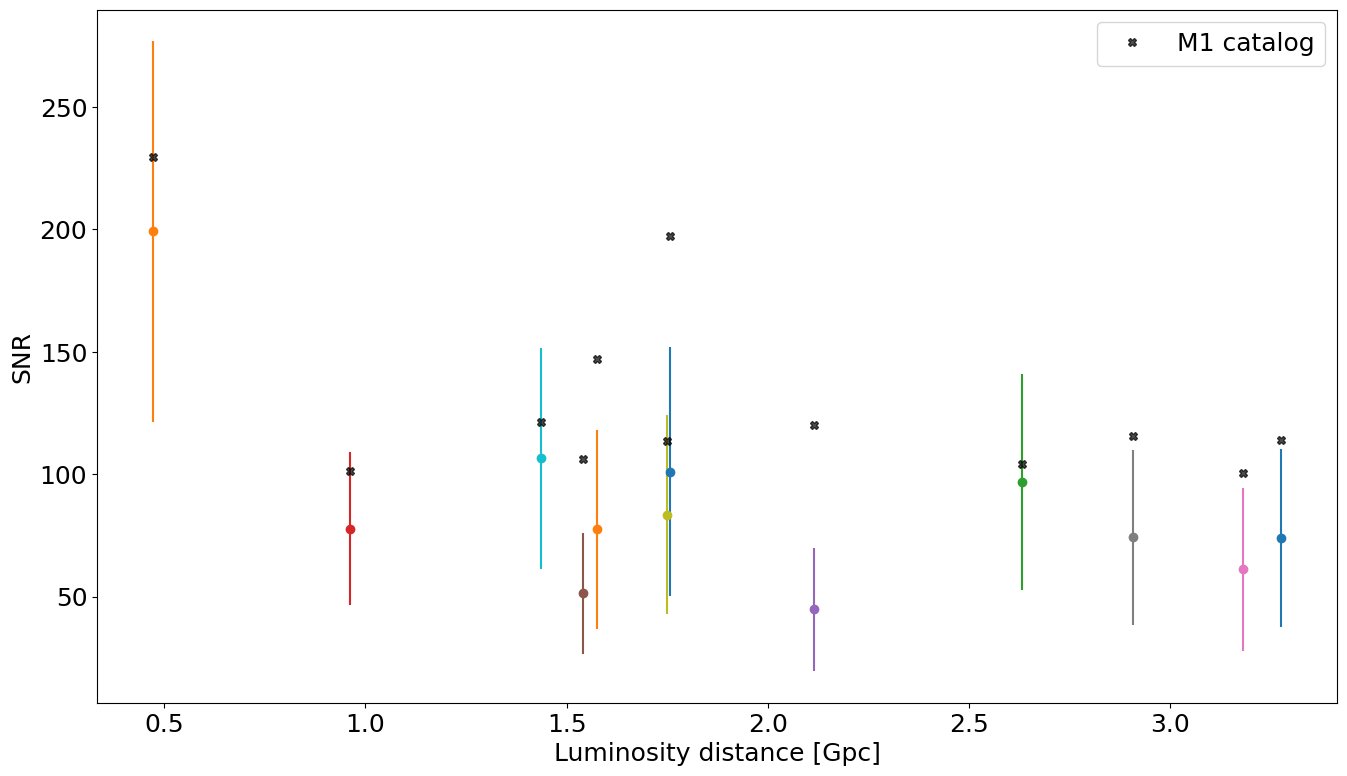

In [30]:
labels = ["tPlunge",  "logmu",  "logM",  "ePlunge",  "nuPlunge",  "gamPlunge",  "phiPlunge",  "costhetaSky",  "phiSky",  "cosLambda",  "alpPlunge",  "SMBHspin",  "costhetaSpin",  "phiSpin",  "Zeta",  "SMBHQuad",  "SNR_tot",  "dist"]
M1_cat = np.loadtxt("EMRIcosmo_M1.txt", skiprows=1)
M1_cat.shape, len(labels)

from few.utils.constants import YRSID_SI
MTsun_fom = 4.9254909491978065e-06
PARSEC_METER_fom = 3.085677581491367e+16
light = 299792458.0
m1_list = np.exp(M1_cat[:, labels.index("logM")])/MTsun_fom
m2_list = np.exp(M1_cat[:, labels.index("logmu")])/MTsun_fom
DL = M1_cat[:, labels.index("dist")] # Gpc
redshift = CosmoInt.get_redshift(DL)
ef = M1_cat[:, labels.index("ePlunge")]
spin = M1_cat[:, labels.index("SMBHspin")]
Tpl_list = M1_cat[:, labels.index("tPlunge")] / YRSID_SI
thS = np.arccos(M1_cat[:, labels.index("costhetaSky")])
phS = M1_cat[:, labels.index("phiSky")]
thK = np.arccos(M1_cat[:, labels.index("costhetaSpin")])
phK = M1_cat[:, labels.index("phiSpin")]
snr = M1_cat[:, labels.index("SNR_tot")]



# per each parameter, plot the distribution of relative precision across sky realizations
plt.figure()
for par in ['snr']:
    for key in source_keys:
        mean_par = np.mean(inference_precision_data[key][par])
        std_par = np.std(inference_precision_data[key][par])
        plt.errorbar(inference_metadata[key]['dist'], mean_par, std_par, fmt='o')#, label=f'Source {key}')

plt.plot(DL, snr, 'kX', alpha=0.7, label='M1 catalog')
plt.xlabel("Luminosity distance [Gpc]")
plt.ylabel("SNR")
plt.legend()
plt.savefig('snr_vs_distance.png', dpi=300, bbox_inches='tight')

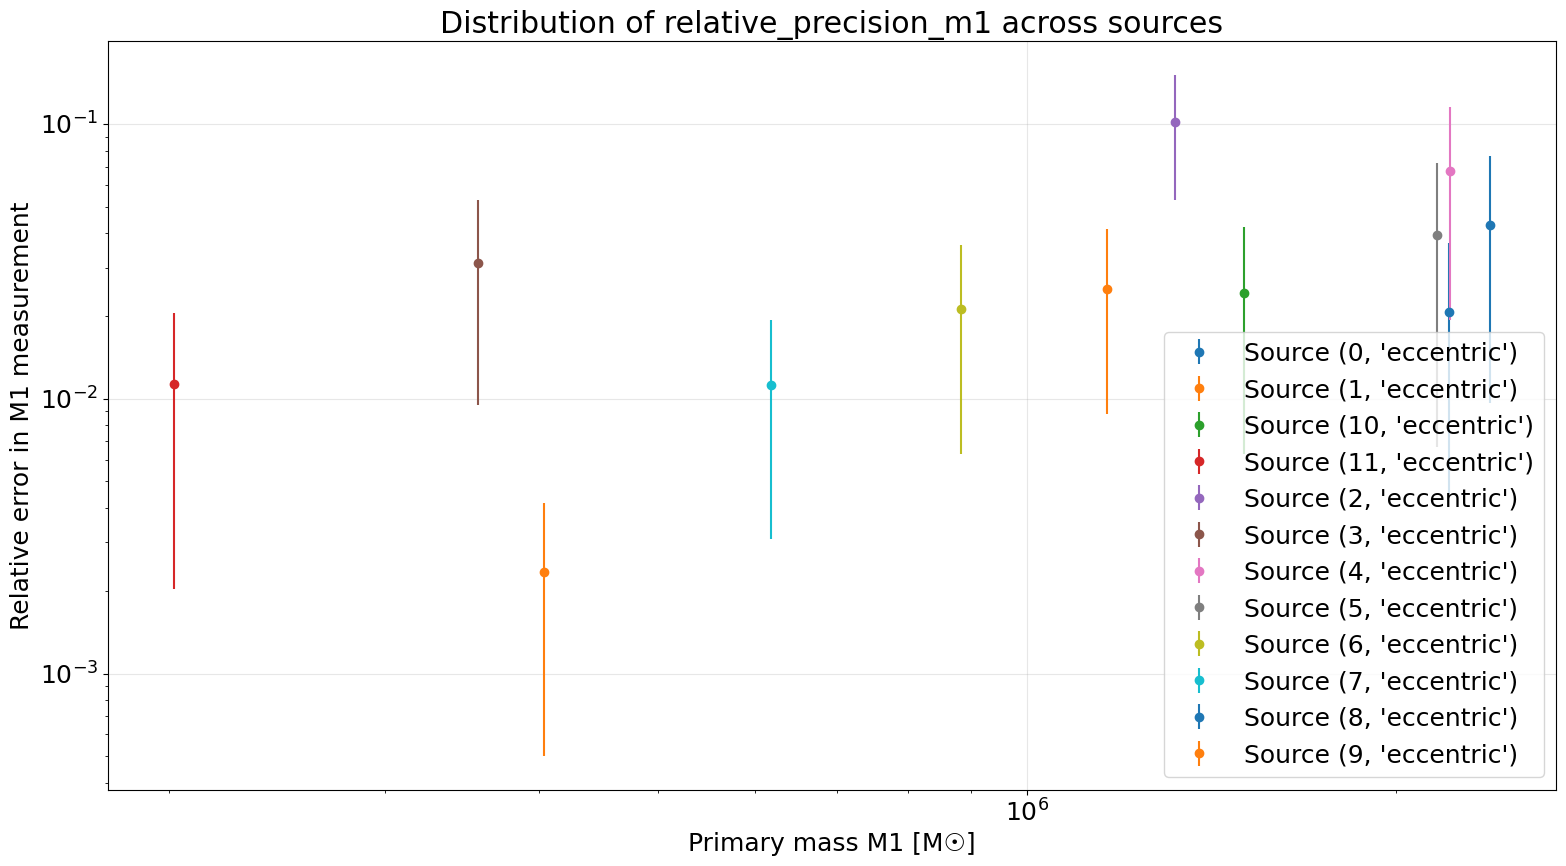

In [31]:
source_keys = list(inference_precision_data.keys())
par_keys = list(inference_precision_data[source_keys[0]].keys())

# per each parameter, plot the distribution of relative precision across sky realizations
plt.figure()
for par in ['relative_precision_m1']:
    
    for key in source_keys:
        mean_par = np.mean(inference_precision_data[key][par])
        std_par = np.std(inference_precision_data[key][par])
        plt.errorbar(inference_metadata[key]['m1'], mean_par, std_par, fmt='o', label=f'Source {key}')
        
    plt.xlabel('Primary mass M1 [M☉]')
    plt.ylabel("Relative error in M1 measurement")
    plt.loglog()
    plt.legend()
    plt.title(f'Distribution of {par} across sources')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
plt.show()

Source (0, 'eccentric') has T=0.40 years, relative difference with FOM T: 2.03
Source (1, 'eccentric') has T=0.97 years, relative difference with FOM T: 0.01
Source (2, 'eccentric') has T=0.06 years, relative difference with FOM T: 23.30
Source (3, 'eccentric') has T=0.28 years, relative difference with FOM T: 4.81
Source (4, 'eccentric') has T=0.19 years, relative difference with FOM T: 3.74
Source (5, 'eccentric') has T=1.27 years, relative difference with FOM T: 0.01
Source (6, 'eccentric') has T=0.40 years, relative difference with FOM T: 3.09
Source (7, 'eccentric') has T=1.68 years, relative difference with FOM T: 0.01
Source (8, 'eccentric') has T=1.58 years, relative difference with FOM T: 0.05
Source (9, 'eccentric') has T=0.22 years, relative difference with FOM T: 1.25
Source (10, 'eccentric') has T=1.32 years, relative difference with FOM T: 0.01
Source (11, 'eccentric') has T=1.51 years, relative difference with FOM T: 0.02


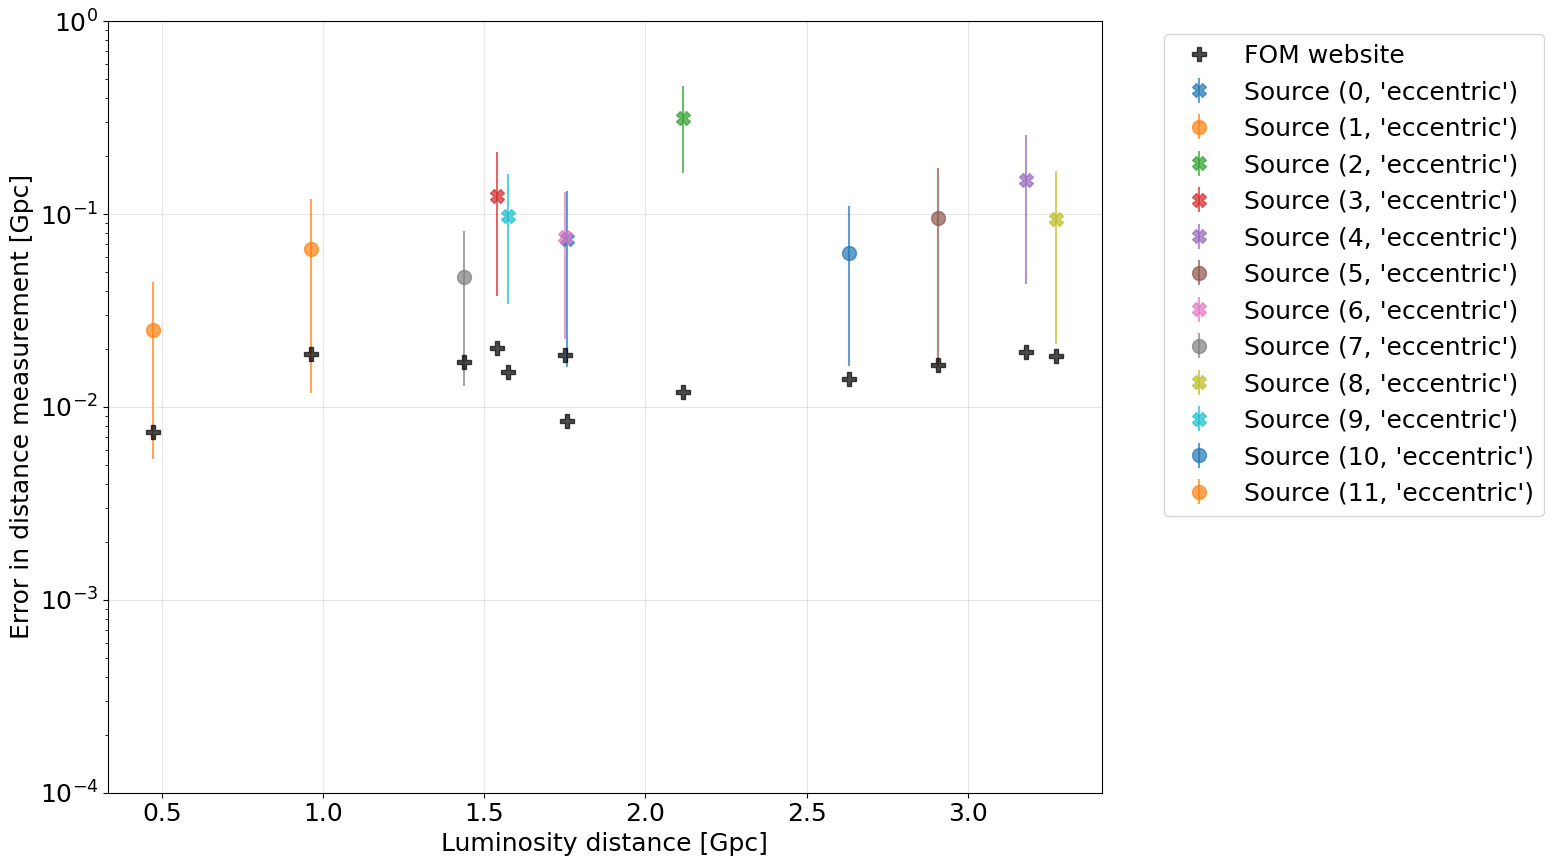

In [32]:
fom_website_ = np.asarray([(0.008426, 1.757600),
(0.007387, 0.473200),
(0.012005, 2.114900),
(0.020115, 1.539700),
(0.019316, 3.181900),
(0.016588, 2.906700),
(0.018616, 1.748900),
(0.017177, 1.436400),
(0.018329, 3.274500),
(0.015146, 1.574800),
(0.013904, 2.631500),
(0.018854, 0.962600)])
sigma_dL_fom = fom_website_[:, 0]
dL_fom = fom_website_[:, 1]

plt.figure()
for par in ['absolute_precision_dist']:
    
    for key in [(ii, 'eccentric') for ii in range(len(source_keys))]:
        mean_par = np.mean(inference_precision_data[key][par])
        std_par = np.std(inference_precision_data[key][par])
        inference_metadata[key]['T']
        relative = np.abs(1-Tpl_list[key[0]]/inference_metadata[key]['T'])
        if relative > 0.05:
            print(f"Source {key} has T={inference_metadata[key]['T']:.2f} years, relative difference with FOM T: {relative:.2f}")
            plt.errorbar(inference_metadata[key]['dist'], mean_par/inference_metadata[key]['dist'], std_par/inference_metadata[key]['dist'], fmt='X', label=f'Source {key}', markersize=10, alpha=0.7)
        else:
            plt.errorbar(inference_metadata[key]['dist'], mean_par/inference_metadata[key]['dist'], std_par/inference_metadata[key]['dist'], fmt='o', label=f'Source {key}', markersize=10, alpha=0.7)
            print(f"Source {key} has T={inference_metadata[key]['T']:.2f} years, relative difference with FOM T: {relative:.2f}")
        
plt.semilogy(dL_fom, sigma_dL_fom, 'kP', label='FOM website', markersize=10, alpha=0.7)
plt.xlabel('Luminosity distance [Gpc]')
plt.ylabel("Error in distance measurement [Gpc]")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.ylim(1e-4, 1.0)
plt.tight_layout()
plt.savefig(f'mean_distance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [33]:
inference_metadata[key]['e0']
Tpl_used = 
plt.plot(Tpl_list, Tpl_used, 'kX')
plt.plot(Tpl_list, Tpl_list, 'k--')


SyntaxError: invalid syntax (3153894833.py, line 2)

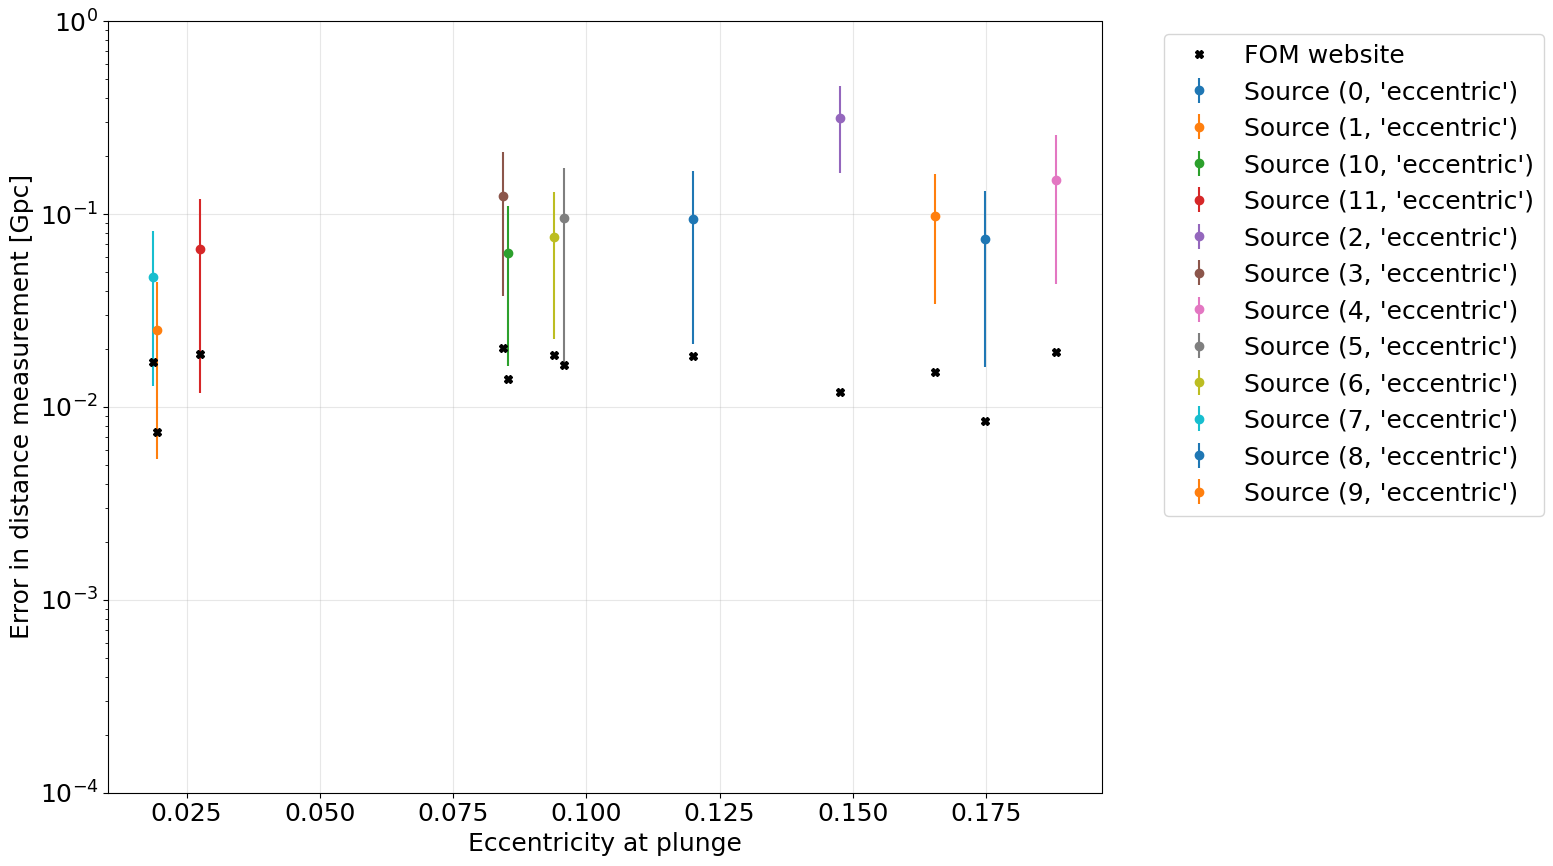

In [ ]:
plt.figure()
for par in ['absolute_precision_dist']:
    
    for key in source_keys:
        mean_par = np.mean(inference_precision_data[key][par])
        std_par = np.std(inference_precision_data[key][par])
        plt.errorbar(inference_metadata[key]['e_f'], mean_par/inference_metadata[key]['dist'], std_par/inference_metadata[key]['dist'], fmt='o', label=f'Source {key}')
        
plt.semilogy(ef, sigma_dL_fom, 'kX', label='FOM website')
plt.xlabel('Eccentricity at plunge')
plt.ylabel("Error in distance measurement [Gpc]")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.ylim(1e-4, 1.0)
plt.tight_layout()
plt.savefig(f'ef_distance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

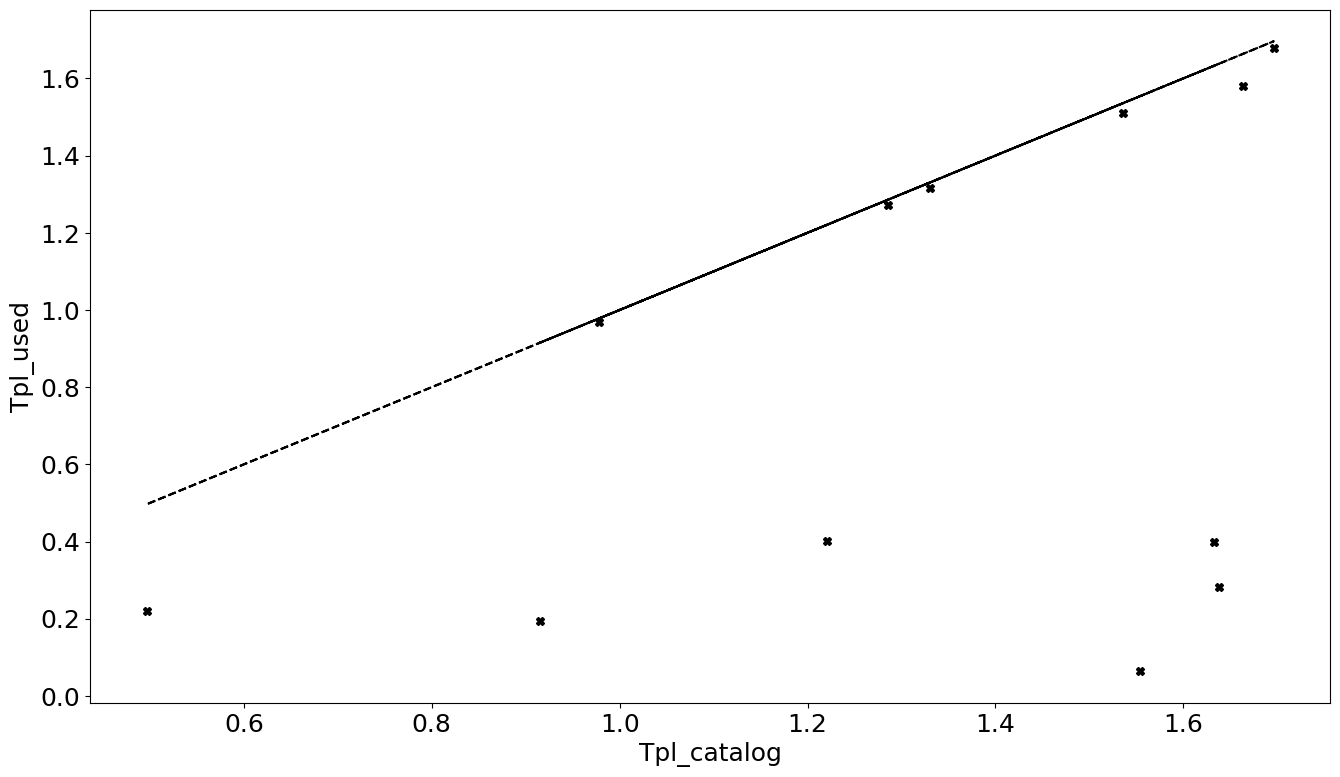

In [ ]:
plt.figure()
Tpl_used = [inference_metadata[(ii, 'eccentric')]['T'] for ii in range(len(source_keys))]
plt.plot(Tpl_list, Tpl_used, 'kX')
plt.plot(Tpl_list, Tpl_list, 'k--')
plt.xlabel('Tpl_catalog')
plt.ylabel('Tpl_used')
plt.show()